
# Análisis Completo del Dataset Edge-IIoTset
#  TFM: IDS/IPS con IA para Raspberry Pi — UCLM 2025-2026
**Alumno:** Luis Ignacio de Luna Gómez

 **Dataset:** Edge-IIoTset (Ferrag et al., 2022) — IEEE Access

 **Referencia:** "Edge-IIoTset: A New Comprehensive Realistic Cyber Security
 Dataset of IoT and IIoT Applications for Centralized and Federated Learning"


---
# FASE 0 — Validación del Entorno
---


In [1]:
import sys
import importlib
import warnings
warnings.filterwarnings('ignore')

print(f"Python: {sys.version}")

REQUIRED = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'xgboost',
    'lightgbm', 'imblearn', 'shap', 'scipy', 'pyarrow', 'psutil', 'tqdm'
]
missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f" Paquetes faltantes: {missing}")
    print("Ejecutar: pip install -r notebooks/requirements_notebook.txt")
else:
    print(" Todas las dependencias instaladas")

import psutil
ram_gb = psutil.virtual_memory().total / 1e9
print(f"RAM total: {ram_gb:.1f} GB")
if ram_gb < 8:
    print("Menos de 8 GB de RAM — se usará carga por chunks")
else:
    print("RAM suficiente para carga completa")

Python: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
 Todas las dependencias instaladas
RAM total: 16.8 GB
RAM suficiente para carga completa


# Verificación de estructura de carpetas y sino crearla


In [2]:
# ========== CONFIGURACIÓN DE RUTAS ==========
from pathlib import Path
import os
import sys

# Ejecución en máquina local
# Detectar si estamos en Colab o máquina local
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Rutas para Google Colab (Google Drive)
    PROJECT_ROOT = Path("/content/drive/MyDrive/TFM")
    print("🌐 Ejecutando en Google Colab")
else:
    # Ejecución en máquina local
    # Buscar la carpeta raíz del proyecto de forma automática
    current_dir = Path.cwd()
    
    # Si estamos en la carpeta notebooks/, subir dos niveles
    if current_dir.name == "notebooks":
        PROJECT_ROOT = current_dir.parent
    else:
        # Si estamos en otra carpeta, buscar hacia arriba
        PROJECT_ROOT = current_dir
        while PROJECT_ROOT.name != "IPS_IDS_Raspberry_IA" and PROJECT_ROOT.parent != PROJECT_ROOT:
            PROJECT_ROOT = PROJECT_ROOT.parent
    
    print(f"🖥️ Ejecutando en máquina local")
    print(f"   Raíz del proyecto: {PROJECT_ROOT}")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"

# Crear las carpetas si no existen
for d in [DATA_RAW, DATA_PROCESSED, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\n✅ Verificando la estructura de carpetas:")
for d in [DATA_RAW, DATA_PROCESSED, FIGURES_DIR]:
    if d.exists() and d.is_dir():
        print(f"   ✓ {d.relative_to(PROJECT_ROOT)}")
    else:
        print(f"   ✗ {d.relative_to(PROJECT_ROOT)} - Error al crear")

🖥️ Ejecutando en máquina local
   Raíz del proyecto: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA

✅ Verificando la estructura de carpetas:
   ✓ data\raw
   ✓ data\processed
   ✓ docs\figures


# Configuración estructura del proyecto

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from tqdm import tqdm
import time
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ========== GOOGLE COLAB: Montar Google Drive ==========
# Descomentar para usar en Google Colab
# En máquina local, las rutas se configuran automáticamente en la celda anterior
try:
    from google.colab import drive
    # Ejecución en máquina local
    # Solo si estamos en Colab
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
        print('✅ Google Drive montado')
    else:
        print('✅ Google Drive ya estaba montado')
except ImportError:
    # Ejecución en máquina local - google.colab no está disponible
    print('✅ Ejecutando en máquina local (google.colab no disponible)')

# Configuración global de visualización
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
sns.set_palette("husl")

print(f"✅ Proyecto: {PROJECT_ROOT}")
print(f"   Datos raw: {DATA_RAW}")
print(f"   Datos procesados: {DATA_PROCESSED}")
print(f"   Figuras: {FIGURES_DIR}")

✅ Ejecutando en máquina local (google.colab no disponible)
✅ Proyecto: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA
   Datos raw: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\raw
   Datos procesados: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\processed
   Figuras: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\docs\figures


---
## FASE 1 — Contexto y Documentación
---

### 1.1 Arquitectura del Testbed Edge-IIoTset

El testbed se organiza en **7 capas**:

| Capa | Tecnología | Función |
|------|-----------|---------|
| Cloud Computing | ThingsBoard IoT Platform | Gestión centralizada de dispositivos |
| NFV | OPNFV Platform | Virtualización de funciones de red |
| Blockchain | Hyperledger Sawtooth | Integridad y trazabilidad |
| Fog Computing | Digital Twin | Procesamiento intermedio |
| SDN | ONOS Controller | Control de red programable |
| Edge Computing | Mosquitto MQTT, Modbus TCP/IP | Procesamiento en el borde |
| IoT/IIoT Perception | 10+ tipos de sensores | Generación de datos |

## 1.2 Sensores IoT del testbed
- Temperatura y humedad (DHT11/DHT22)
 - Ultrasónico (HC-SR04)
 - Nivel de agua
 - pH
 - Humedad del suelo
 - Ritmo cardíaco
 - Sensor de llama
 - Sensor infrarrojo

### 1.3 Protocolos de conectividad
 - **MQTT** (Message Queuing Telemetry Transport) — IoT ligero
 - **Modbus TCP/IP** — Protocolo industrial IIoT
 - **CoAP** (Constrained Application Protocol) — IoT restringido
 - **HTTP/HTTPS** — Comunicación web estándar

 ### 1.4 Taxonomía de Amenazas y Mapeo MITRE ATT&CK

In [9]:
# ========== FASE 1.4: TAXONOMÍA DE AMENAZAS Y MAPEO MITRE ATT&CK ==========

# Verificar que la celda de imports se ejecutó
if 'PROJECT_ROOT' not in dir():
    raise RuntimeError("⚠️ Ejecuta primero la celda de configuración de rutas que define PROJECT_ROOT.")

# Documentación estructurada de ataques
ATTACK_TAXONOMY = {
    "DoS/DDoS": {
        "ataques": ["DDoS_UDP", "DDoS_ICMP", "DDoS_TCP", "DDoS_HTTP"],
        "descripcion": "Inundación de tráfico para denegar servicio a dispositivos IoT/IIoT edge",
        "mitre_ids": ["T1498", "T1499"],
        "mitre_names": ["Network Denial of Service", "Endpoint Denial of Service"],
        "protocolos_afectados": ["UDP", "ICMP", "TCP", "HTTP"],
        "impacto": "Indisponibilidad de servicios IoT críticos"
    },
    "Information Gathering": {
        "ataques": ["Port_Scanning", "OS_Fingerprinting", "Vulnerability_Scanner"],
        "descripcion": "Reconocimiento activo: escaneo de puertos, detección de SO y vulnerabilidades",
        "mitre_ids": ["T1046", "T1592", "T1595"],
        "mitre_names": ["Network Service Scanning", "Gather Victim Host Info", "Active Scanning"],
        "protocolos_afectados": ["TCP", "UDP", "ICMP"],
        "impacto": "Obtención de información para ataques posteriores"
    },
    "Man-in-the-Middle": {
        "ataques": ["MITM", "DNS_Spoofing"],
        "descripcion": "Interceptación y manipulación de comunicaciones entre dispositivos",
        "mitre_ids": ["T1557", "T1557.002"],
        "mitre_names": ["Adversary-in-the-Middle", "ARP Cache Poisoning"],
        "protocolos_afectados": ["ARP", "DNS"],
        "impacto": "Interceptación de datos sensibles, redirección de tráfico"
    },
    "Injection": {
        "ataques": ["SQL_Injection", "XSS", "Uploading_Attack"],
        "descripcion": "Inyección de código/comandos maliciosos en aplicaciones IoT",
        "mitre_ids": ["T1190", "T1059"],
        "mitre_names": ["Exploit Public-Facing Application", "Command and Scripting Interpreter"],
        "protocolos_afectados": ["HTTP", "HTTPS"],
        "impacto": "Ejecución remota de código, robo de datos"
    },
    "Malware": {
        "ataques": ["Backdoor", "Ransomware", "Password"],
        "descripcion": "Software malicioso: puertas traseras, cifrado de datos, fuerza bruta",
        "mitre_ids": ["T1059.004", "T1486", "T1110"],
        "mitre_names": ["Unix Shell (Backdoor)", "Data Encrypted for Impact", "Brute Force"],
        "protocolos_afectados": ["TCP", "HTTP", "SSH"],
        "impacto": "Control remoto, extorsión, acceso no autorizado"
    }
}

# Mostrar tabla resumen
print("=" * 100)
print("TAXONOMÍA DE AMENAZAS — Edge-IIoTset → MITRE ATT&CK for IoT")
print("=" * 100)
for cat, info in ATTACK_TAXONOMY.items():
    print(f"\n🔴 {cat}")
    print(f"   Descripción: {info['descripcion']}")
    print(f"   Ataques: {', '.join(info['ataques'])}")
    print(f"   MITRE: {', '.join(f'{mid} ({mn})' for mid, mn in zip(info['mitre_ids'], info['mitre_names']))}")
    print(f"   Protocolos: {', '.join(info['protocolos_afectados'])}")
    print(f"   Impacto: {info['impacto']}")

total_attacks = sum(len(v["ataques"]) for v in ATTACK_TAXONOMY.values())
print(f"\nTotal: {total_attacks} tipos de ataque + Normal = {total_attacks + 1} clases")

# Ejecución en máquina local: Guardar taxonomía como JSON para la memoria
taxonomy_path = PROJECT_ROOT / "docs" / "attack_taxonomy.json"
with open(taxonomy_path, 'w', encoding='utf-8') as f:
    json.dump(ATTACK_TAXONOMY, f, indent=2, ensure_ascii=False)
print(f"\n📄 Taxonomía guardada en: {taxonomy_path}")

TAXONOMÍA DE AMENAZAS — Edge-IIoTset → MITRE ATT&CK for IoT

🔴 DoS/DDoS
   Descripción: Inundación de tráfico para denegar servicio a dispositivos IoT/IIoT edge
   Ataques: DDoS_UDP, DDoS_ICMP, DDoS_TCP, DDoS_HTTP
   MITRE: T1498 (Network Denial of Service), T1499 (Endpoint Denial of Service)
   Protocolos: UDP, ICMP, TCP, HTTP
   Impacto: Indisponibilidad de servicios IoT críticos

🔴 Information Gathering
   Descripción: Reconocimiento activo: escaneo de puertos, detección de SO y vulnerabilidades
   Ataques: Port_Scanning, OS_Fingerprinting, Vulnerability_Scanner
   MITRE: T1046 (Network Service Scanning), T1592 (Gather Victim Host Info), T1595 (Active Scanning)
   Protocolos: TCP, UDP, ICMP
   Impacto: Obtención de información para ataques posteriores

🔴 Man-in-the-Middle
   Descripción: Interceptación y manipulación de comunicaciones entre dispositivos
   Ataques: MITM, DNS_Spoofing
   MITRE: T1557 (Adversary-in-the-Middle), T1557.002 (ARP Cache Poisoning)
   Protocolos: ARP, DNS
 

---
## FASE 2 — Extracción y Carga de Datos
---



In [10]:
# ========== FASE 2.1: LOCALIZAR DATASET ==========
# El dataset debe estar en:
#   - Máquina local: data/raw/
#   - Google Colab: /content/drive/MyDrive/TFM/data/raw/

# Buscar el CSV principal del dataset
def find_dataset_file(base_dir, filename="DNN-EdgeIIoT-dataset.csv"):
    """Busca el archivo CSV del dataset recursivamente."""
    # Buscar archivo específico
    for path in Path(base_dir).rglob(filename):
        return path
    
    # Buscar variantes con nombres similares
    for path in Path(base_dir).rglob("*.csv"):
        name_lower = path.name.lower()
        if "edgeiiot" in name_lower or "dnn" in name_lower:
            return path
    
    return None

# Localizar el archivo CSV
csv_path = find_dataset_file(DATA_RAW)

if csv_path:
    print(f"✅ Dataset encontrado: {csv_path}")
    print(f"   Tamaño: {csv_path.stat().st_size / 1e6:.1f} MB")
else:
    print(f"❌ No se encontró el dataset en {DATA_RAW}")
    print(f"\n📥 Para descargar el dataset:")
    print(f"   1. Ve a: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")
    print(f"   2. Descarga el archivo CSV")
    
    if IN_COLAB:
        print(f"\n   📱 En Google Colab:")
        print(f"      - Descarga manualmente el CSV")
        print(f"      - Sube a Google Drive en: My Drive/TFM/data/raw/")
    else:
        print(f"\n   🖥️ En máquina local:")
        print(f"      - Coloca el CSV en: {DATA_RAW}")
    
    raise FileNotFoundError(f"Dataset no encontrado en {DATA_RAW}")

✅ Dataset encontrado: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\raw\DNN-EdgeIIoT-dataset.csv
   Tamaño: 1217.4 MB


In [11]:
# ========== FASE 2.2: CARGA CON VALIDACIÓN DE INTEGRIDAD ==========

PARQUET_PATH = DATA_PROCESSED / "edge_iiot_dataset.parquet"

def load_and_validate_dataset(csv_path, parquet_path):
    """Carga CSV con validación de integridad y convierte a Parquet."""
    # Si existe Parquet previo, cargar directamente (más rápido)
    if parquet_path.exists():
        print(f"📂 Cargando desde Parquet (caché): {parquet_path}")
        df = pd.read_parquet(parquet_path)
        print(f"   Shape: {df.shape}")
        return df

    if csv_path is None:
        raise FileNotFoundError("No se encontró el CSV del dataset.")

    print(f"📂 Cargando CSV: {csv_path}")
    # Carga con manejo de errores (saltos de línea en strings, encoding)
    try:
        df = pd.read_csv(csv_path, low_memory=False, on_bad_lines='warn')
    except TypeError:
        # Ejecución en máquina local: Versiones antiguas de pandas
        df = pd.read_csv(csv_path, low_memory=False, error_bad_lines=False)

    print(f"   Shape: {df.shape}")

    # --- Validación de integridad ---
    print("\n🔍 Validación de integridad:")

    # Verificar columna de etiqueta
    label_candidates = ['Attack_type', 'attack_type', 'Attack_label',
                        'attack_label', 'label', 'Label', 'type']
    label_col = None
    for col in label_candidates:
        if col in df.columns:
            label_col = col
            break

    if label_col is None:
        print("   ⚠️ No se encontró columna de etiqueta estándar.")
        print(f"   Columnas disponibles: {list(df.columns[-5:])}")
        # Intentar última columna como etiqueta
        label_col = df.columns[-1]
        print(f"   Usando última columna como etiqueta: '{label_col}'")
    else:
        print(f"   ✅ Columna de etiqueta: '{label_col}'")

    # Renombrar a nombre estándar si es necesario
    if label_col != 'Attack_type':
        df.rename(columns={label_col: 'Attack_type'}, inplace=True)
        print(f"   Renombrada '{label_col}' → 'Attack_type'")

    # Distribución inmediata de clases
    print(f"\n   📊 Distribución de clases:")
    class_dist = df['Attack_type'].value_counts()
    for cls, count in class_dist.items():
        pct = count / len(df) * 100
        print(f"      {cls:<30s} {count:>10,d}  ({pct:5.2f}%)")

    # Verificar número de columnas
    n_cols = df.shape[1]
    if n_cols < 10:
        print(f"   ⚠️ Solo {n_cols} columnas — ¿archivo correcto?")
    else:
        print(f"   ✅ {n_cols} columnas detectadas")

    # Guardar como Parquet para caché
    print(f"\n💾 Guardando Parquet en: {parquet_path}")
    df.to_parquet(parquet_path, index=False)
    parquet_size = parquet_path.stat().st_size / 1e6
    csv_size = csv_path.stat().st_size / 1e6
    compression = (1 - parquet_size/csv_size)*100 if csv_size > 0 else 0
    print(f"   CSV: {csv_size:.1f} MB → Parquet: {parquet_size:.1f} MB "
          f"(compresión: {compression:.0f}%)")

    return df

df = load_and_validate_dataset(csv_path, PARQUET_PATH)
print(f"\n✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

📂 Cargando desde Parquet (caché): c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\processed\edge_iiot_dataset.parquet
   Shape: (2219201, 63)

✅ Dataset cargado: 2,219,201 filas × 63 columnas


---
## FASE 3 — Análisis Exploratorio de Datos (EDA)
---

In [12]:
# === 3.1 Información general del dataset ===
print("=" * 80)
print("3.1 — INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nShape: {df.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print(f"\n--- Tipos de datos ---")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columnas")

print(f"\n--- Primeras 5 filas ---")
df.head()

3.1 — INFORMACIÓN GENERAL DEL DATASET

Shape: (2219201, 63)
Memoria: 1874.6 MB

--- Tipos de datos ---
  float64: 42 columnas
  str: 20 columnas
  int64: 1 columnas

--- Primeras 5 filas ---


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [13]:
# === 3.2 Calidad de datos: Nulls, duplicados, inf ===
print("=" * 80)
print("3.2 — CALIDAD DE DATOS")
print("=" * 80)

# Valores nulos
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
print(f"\nColumnas con valores nulos: {len(null_cols)}")
if len(null_cols) > 0:
    for col, count in null_cols.items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")

# CRÍTICO: Detectar y tratar valores infinitos ANTES de cualquier análisis
# El dataset tiene inf en columnas de tasas de flujo (bytes/s cuando duración=0)
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df[numeric_cols].values) if len(numeric_cols) > 0 else np.array([])
if inf_mask.any():
    inf_count = inf_mask.sum()
    print(f"\n⚠️ Valores infinitos detectados: {inf_count:,}")
    inf_per_col = pd.Series(inf_mask.sum(axis=0), index=numeric_cols)
    inf_cols = inf_per_col[inf_per_col > 0]
    for col, count in inf_cols.items():
        print(f"  {col}: {count:,} inf values")
    # Reemplazar inf por NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print(f"  ✅ Valores infinitos convertidos a NaN")
else:
    print("\n✅ No se detectaron valores infinitos")

# Total de NaN después de conversión de inf
total_nan = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nTotal NaN (incluyendo inf→NaN): {total_nan:,} ({total_nan/total_cells*100:.3f}%)")

# Duplicados
n_duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_duplicates:,} ({n_duplicates/len(df)*100:.2f}%)")
if n_duplicates > 0:
    print("  ℹ️ Los duplicados se mantienen — en tráfico de red es normal")

3.2 — CALIDAD DE DATOS

Columnas con valores nulos: 0

✅ No se detectaron valores infinitos

Total NaN (incluyendo inf→NaN): 0 (0.000%)

Filas duplicadas: 815 (0.04%)
  ℹ️ Los duplicados se mantienen — en tráfico de red es normal


In [14]:
# === 3.3 Distribución de clases y cuantificación del desbalanceo ===
print("=" * 80)
print("3.3 — DISTRIBUCIÓN DE CLASES Y DESBALANCEO")
print("=" * 80)

class_counts = df['Attack_type'].value_counts()
class_pcts = df['Attack_type'].value_counts(normalize=True) * 100

# Tabla de distribución
dist_table = pd.DataFrame({
    'Clase': class_counts.index,
    'Muestras': class_counts.values,
    'Porcentaje': class_pcts.values
})

# Ratio respecto a Normal (o clase mayoritaria)
majority_class = class_counts.index[0]
majority_count = class_counts.iloc[0]
dist_table['Ratio_1:N'] = (majority_count / dist_table['Muestras']).round(1)
dist_table = dist_table.reset_index(drop=True)

print(f"\nClase mayoritaria: '{majority_class}' ({majority_count:,} muestras)")
print(f"\n{dist_table.to_string(index=False)}")

# Calcular métricas de desbalanceo
imbalance_ratio = majority_count / class_counts.min()
print(f"\n📊 Ratio de desbalanceo máximo: 1:{imbalance_ratio:.0f}")
print(f"   Clase más rara: '{class_counts.index[-1]}' ({class_counts.iloc[-1]:,})")

# Ejecución en máquina local: Guardar tabla para la memoria
dist_table.to_csv(PROJECT_ROOT / "docs" / "class_distribution.csv", index=False)
print(f"\n📄 Distribución de clases guardada en docs/class_distribution.csv")

3.3 — DISTRIBUCIÓN DE CLASES Y DESBALANCEO

Clase mayoritaria: 'Normal' (1,615,643 muestras)

                Clase  Muestras  Porcentaje  Ratio_1:N
               Normal   1615643   72.802914        1.0
             DDoS_UDP    121568    5.478008       13.3
            DDoS_ICMP    116436    5.246753       13.9
        SQL_injection     51203    2.307272       31.6
             Password     50153    2.259958       32.2
Vulnerability_scanner     50110    2.258020       32.2
             DDoS_TCP     50062    2.255857       32.3
            DDoS_HTTP     49911    2.249053       32.4
            Uploading     37634    1.695836       42.9
             Backdoor     24862    1.120313       65.0
        Port_Scanning     22564    1.016762       71.6
                  XSS     15915    0.717150      101.5
           Ransomware     10925    0.492294      147.9
                 MITM      1214    0.054704     1330.8
       Fingerprinting      1001    0.045106     1614.0

📊 Ratio de desbalanceo má

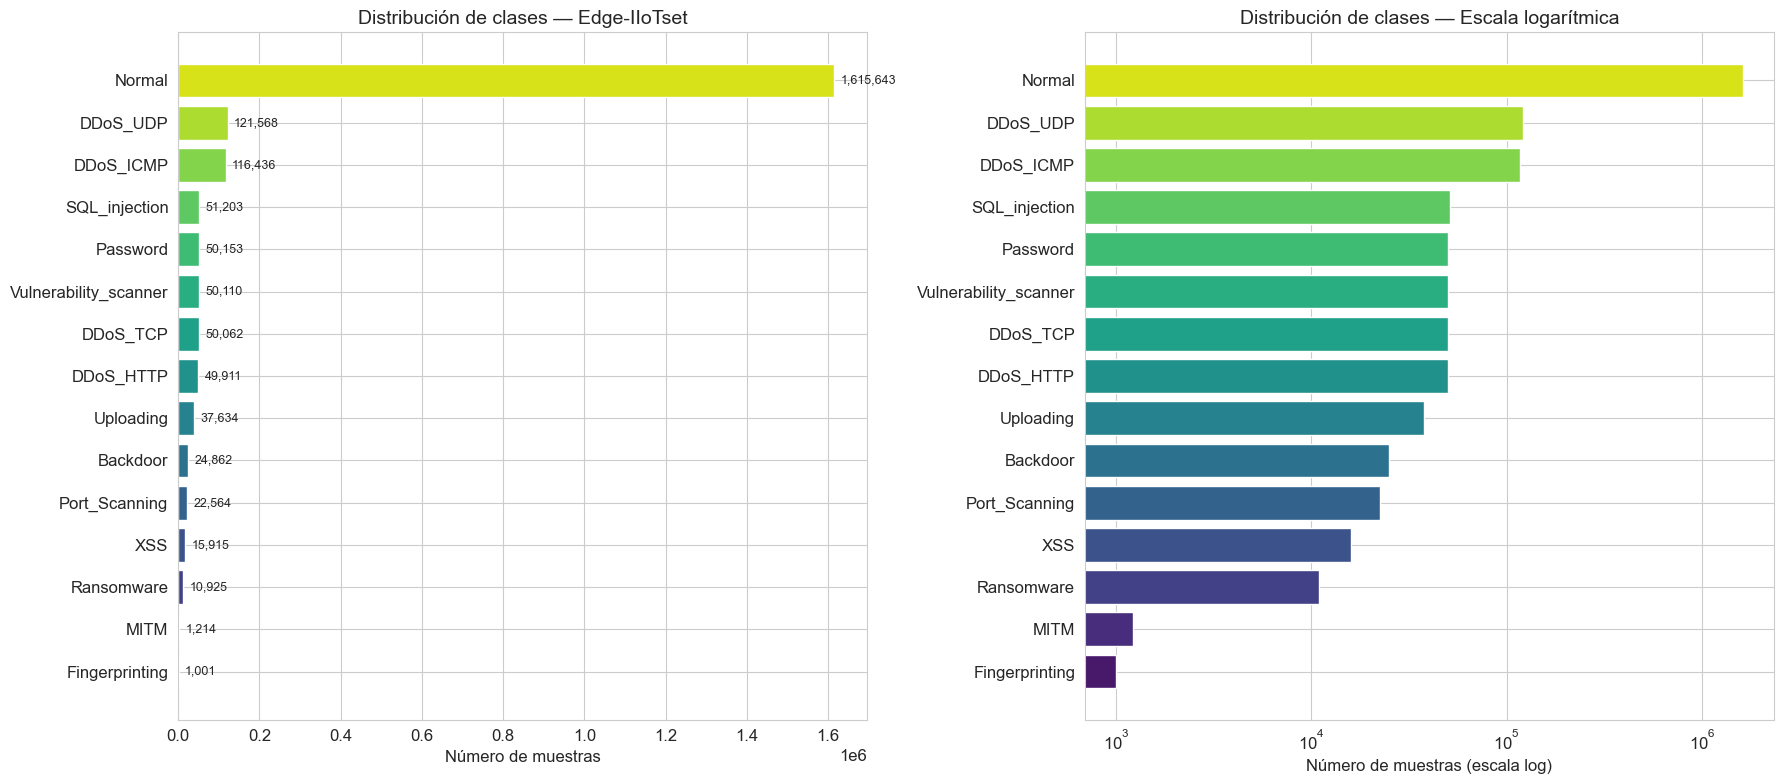

📄 Guardado: c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\docs\figures\class_distribution.png


In [15]:
# Gráfico de distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Barplot
colors = sns.color_palette("viridis", len(class_counts))
bars = axes[0].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors)
axes[0].set_xlabel('Número de muestras')
axes[0].set_title('Distribución de clases — Edge-IIoTset')
for bar, val in zip(bars, class_counts.values[::-1]):
    axes[0].text(bar.get_width() + max(class_counts) * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Log-scale barplot (para ver clases minoritarias)
axes[1].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors)
axes[1].set_xscale('log')
axes[1].set_xlabel('Número de muestras (escala log)')
axes[1].set_title('Distribución de clases — Escala logarítmica')

plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "class_distribution.png")
plt.show()
print(f"📄 Guardado: {FIGURES_DIR / 'class_distribution.png'}")

In [16]:
# === 3.4 Estadísticas descriptivas ===
print("=" * 80)
print("3.4 — ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)

# Asegurarse de que numeric_cols está definido (por si se saltó la celda 3.2)
if 'numeric_cols' not in dir():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("⚠️ Definiendo numeric_cols localmente (celda 3.2 no ejecutada)")

# Estadísticas globales
desc = df[numeric_cols].describe().T
desc['null_pct'] = df[numeric_cols].isnull().mean() * 100
desc['nunique'] = df[numeric_cols].nunique()
print("\nEstadísticas globales (top 20 features por desviación estándar):")
print(desc.sort_values('std', ascending=False).head(20).to_string())

# Estadísticas por clase (resumen)
print("\n--- Medias por clase (primeras 10 features numéricas) ---")
first_10_num = numeric_cols[:10]
class_means = df.groupby('Attack_type')[first_10_num].mean()
print(class_means.round(3).to_string())

3.4 — ESTADÍSTICAS DESCRIPTIVAS

Estadísticas globales (top 20 features por desviación estándar):
                             count          mean           std  min         25%           50%           75%           max  null_pct  nunique
tcp.ack_raw              2219201.0  1.573687e+09  1.337361e+09  0.0  42609615.0  1.426945e+09  2.506984e+09  4.294947e+09       0.0   915938
tcp.ack                  2219201.0  2.278400e+07  1.649033e+08  0.0         1.0  6.000000e+00  5.900000e+01  3.949529e+09       0.0   146980
tcp.seq                  2219201.0  8.682862e+06  3.476928e+07  0.0         1.0  5.000000e+00  5.900000e+01  4.294967e+09       0.0   213310
icmp.transmit_timestamp  2219201.0  2.877556e+03  4.705188e+05  0.0         0.0  0.000000e+00  0.000000e+00  7.728902e+07       0.0       84
udp.stream               2219201.0  7.198890e+04  3.654767e+05  0.0         0.0  0.000000e+00  0.000000e+00  2.898776e+06       0.0   120450
dns.qry.name             2219201.0  7.374416e+03  1.1917

In [17]:
# === 3.5 Detección de features constantes o casi constantes ===
print("=" * 80)
print("3.5 — FEATURES CONSTANTES O CASI CONSTANTES")
print("=" * 80)

VARIANCE_THRESHOLD = 1e-5
variances = df[numeric_cols].var()
constant_features = variances[variances < VARIANCE_THRESHOLD].index.tolist()
near_constant = variances[(variances >= VARIANCE_THRESHOLD) & (variances < 0.01)].index.tolist()

print(f"\nFeatures con varianza < {VARIANCE_THRESHOLD} (constantes): {len(constant_features)}")
for f in constant_features:
    unique_vals = df[f].nunique()
    print(f"  {f}: var={variances[f]:.2e}, unique={unique_vals}")

print(f"\nFeatures con varianza < 0.01 (casi constantes): {len(near_constant)}")
for f in near_constant[:10]:
    print(f"  {f}: var={variances[f]:.6f}, unique={df[f].nunique()}")

# Features con un solo valor único
single_value = [c for c in df.columns if df[c].nunique() <= 1]
print(f"\nFeatures con ≤1 valor único: {len(single_value)}")
if single_value:
    print(f"  → Se eliminarán: {single_value}")


3.5 — FEATURES CONSTANTES O CASI CONSTANTES

Features con varianza < 1e-05 (constantes): 4
  icmp.unused: var=0.00e+00, unique=1
  http.tls_port: var=0.00e+00, unique=1
  dns.qry.type: var=0.00e+00, unique=1
  mqtt.msg_decoded_as: var=0.00e+00, unique=1

Features con varianza < 0.01 (casi constantes): 4
  arp.opcode: var=0.004683, unique=3
  dns.retransmit_request: var=0.000022, unique=2
  dns.retransmit_request_in: var=0.000018, unique=2
  mbtcp.unit_id: var=0.000190, unique=6

Features con ≤1 valor único: 4
  → Se eliminarán: ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']


3.6 — CORRELACIÓN DE FEATURES
Features para análisis de correlación: 39

--- Calculando correlación de Pearson ---


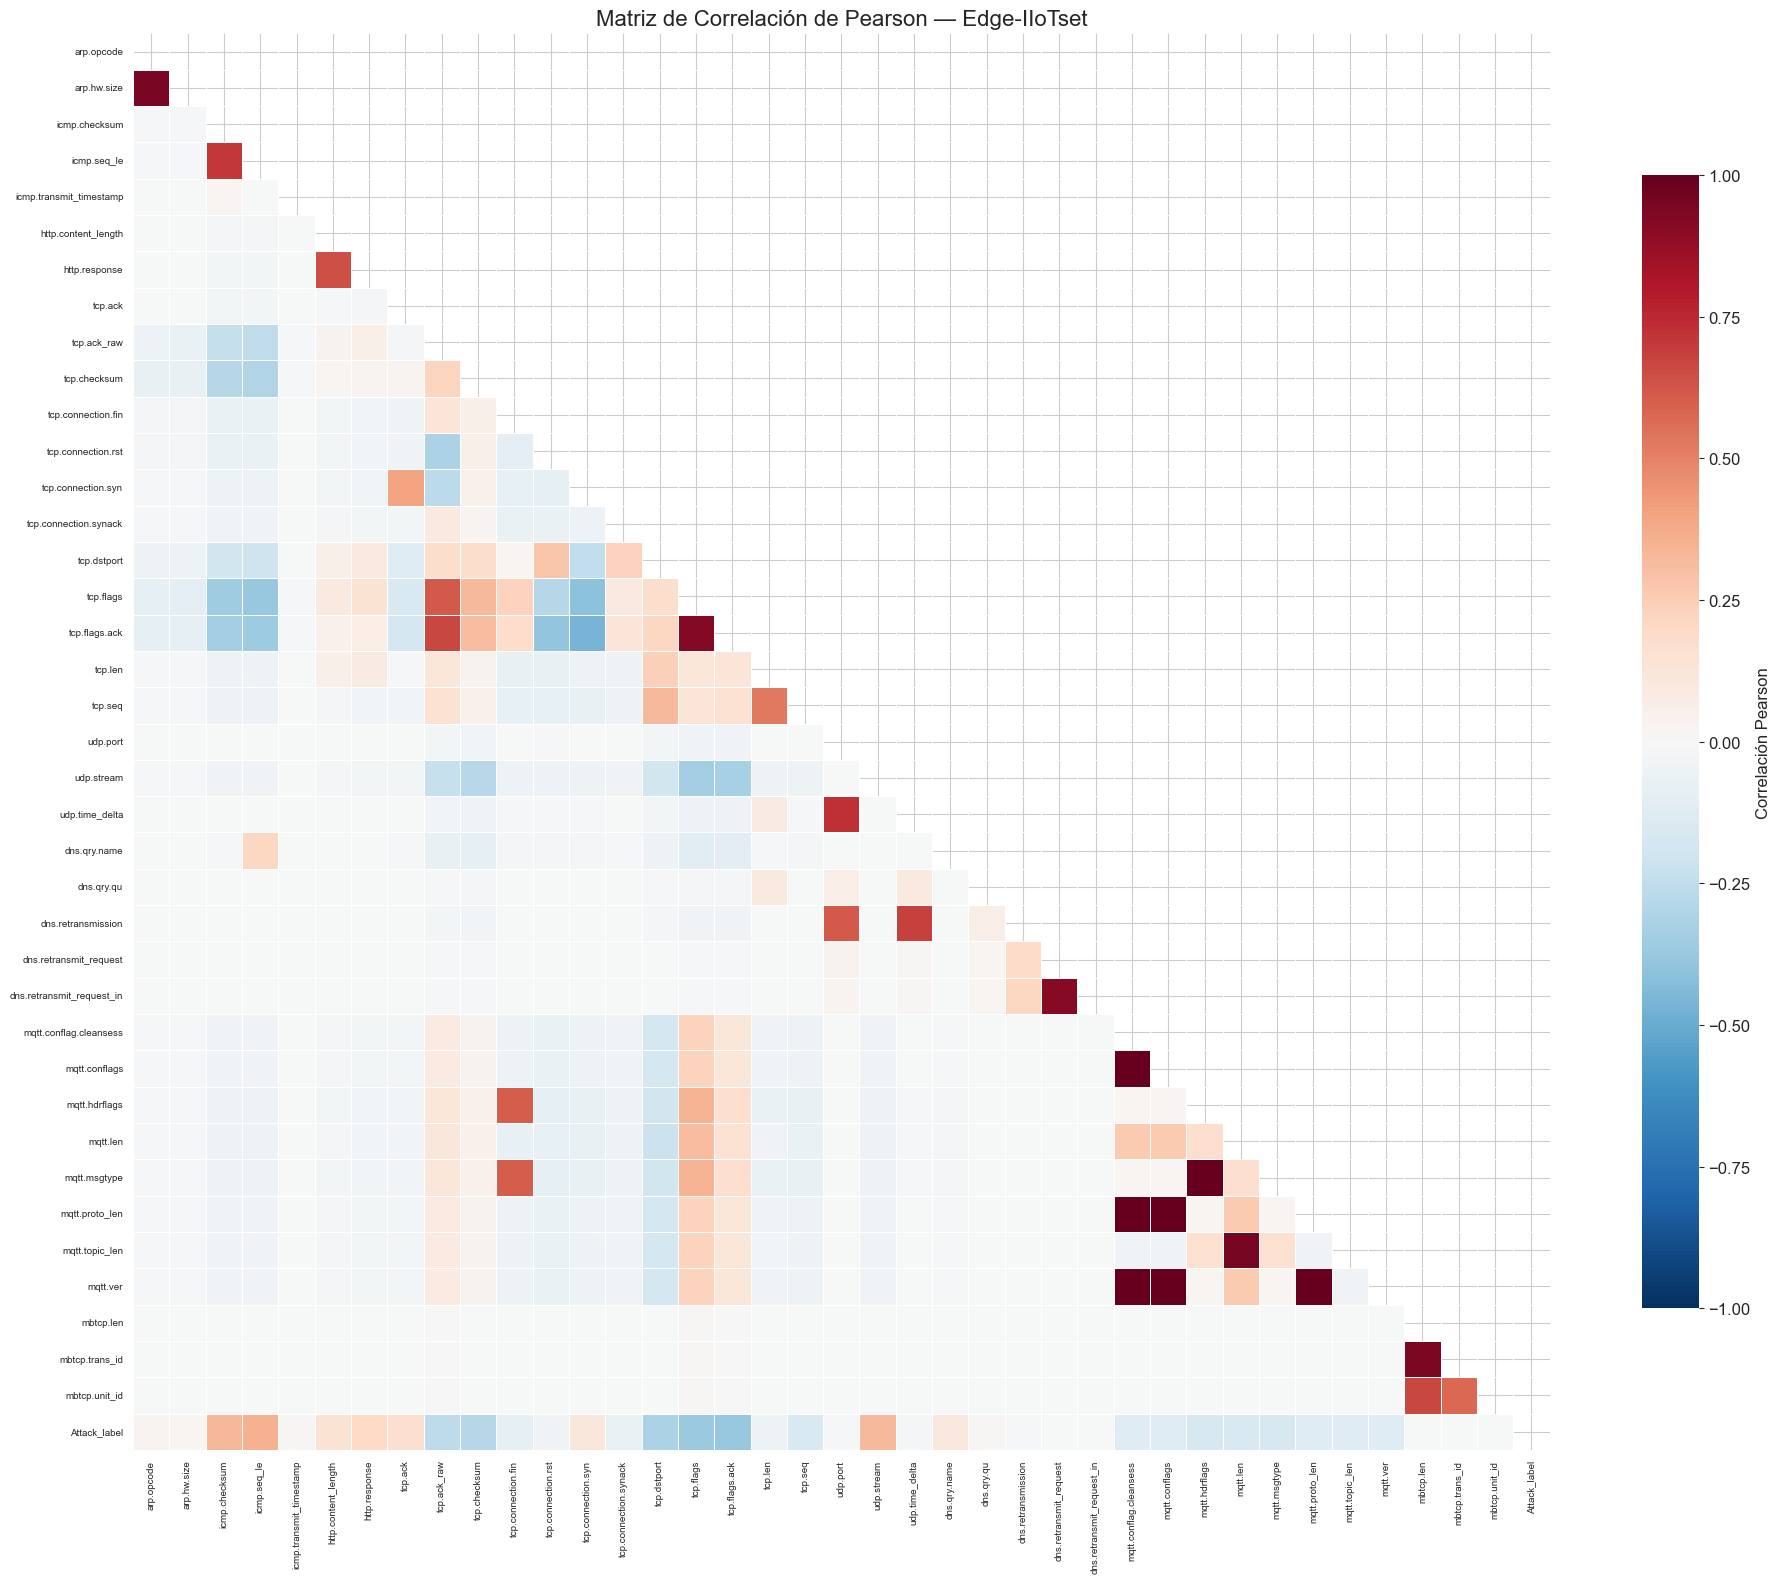


Pares con |r| > 0.95: 8
  mqtt.conflag.cleansess ↔ mqtt.conflags: r=1.0
  mqtt.conflag.cleansess ↔ mqtt.proto_len: r=1.0
  mqtt.conflag.cleansess ↔ mqtt.ver: r=1.0
  mqtt.conflags ↔ mqtt.proto_len: r=1.0
  mqtt.conflags ↔ mqtt.ver: r=1.0
  mqtt.hdrflags ↔ mqtt.msgtype: r=1.0
  mqtt.proto_len ↔ mqtt.ver: r=1.0
  mqtt.len ↔ mqtt.topic_len: r=0.9534


In [18]:
# === 3.6 Correlación de features (Pearson + Spearman) ===
print("=" * 80)
print("3.6 — CORRELACIÓN DE FEATURES")
print("=" * 80)

# Eliminar constantes para el análisis
analysis_cols = [c for c in numeric_cols if c not in constant_features + single_value]
print(f"Features para análisis de correlación: {len(analysis_cols)}")

# Pearson
print("\n--- Calculando correlación de Pearson ---")
# Usar sample si el dataset es muy grande para velocidad
if len(df) > 100_000:
    df_sample = df[analysis_cols].sample(n=100_000, random_state=42)
else:
    df_sample = df[analysis_cols]

corr_pearson = df_sample.corr(method='pearson')

# Heatmap Pearson
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación Pearson"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Matriz de Correlación de Pearson — Edge-IIoTset', fontsize=16)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "correlation_heatmap_pearson.png")
plt.show()

# Pares altamente correlacionados
high_corr_threshold = 0.95
high_corr_pairs = []
for i in range(len(corr_pearson.columns)):
    for j in range(i+1, len(corr_pearson.columns)):
        val = corr_pearson.iloc[i, j]
        if abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_pearson.columns[i],
                corr_pearson.columns[j],
                round(val, 4)
            ))

print(f"\nPares con |r| > {high_corr_threshold}: {len(high_corr_pairs)}")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:20]:
    print(f"  {f1} ↔ {f2}: r={r}")


--- Calculando correlación de Spearman ---


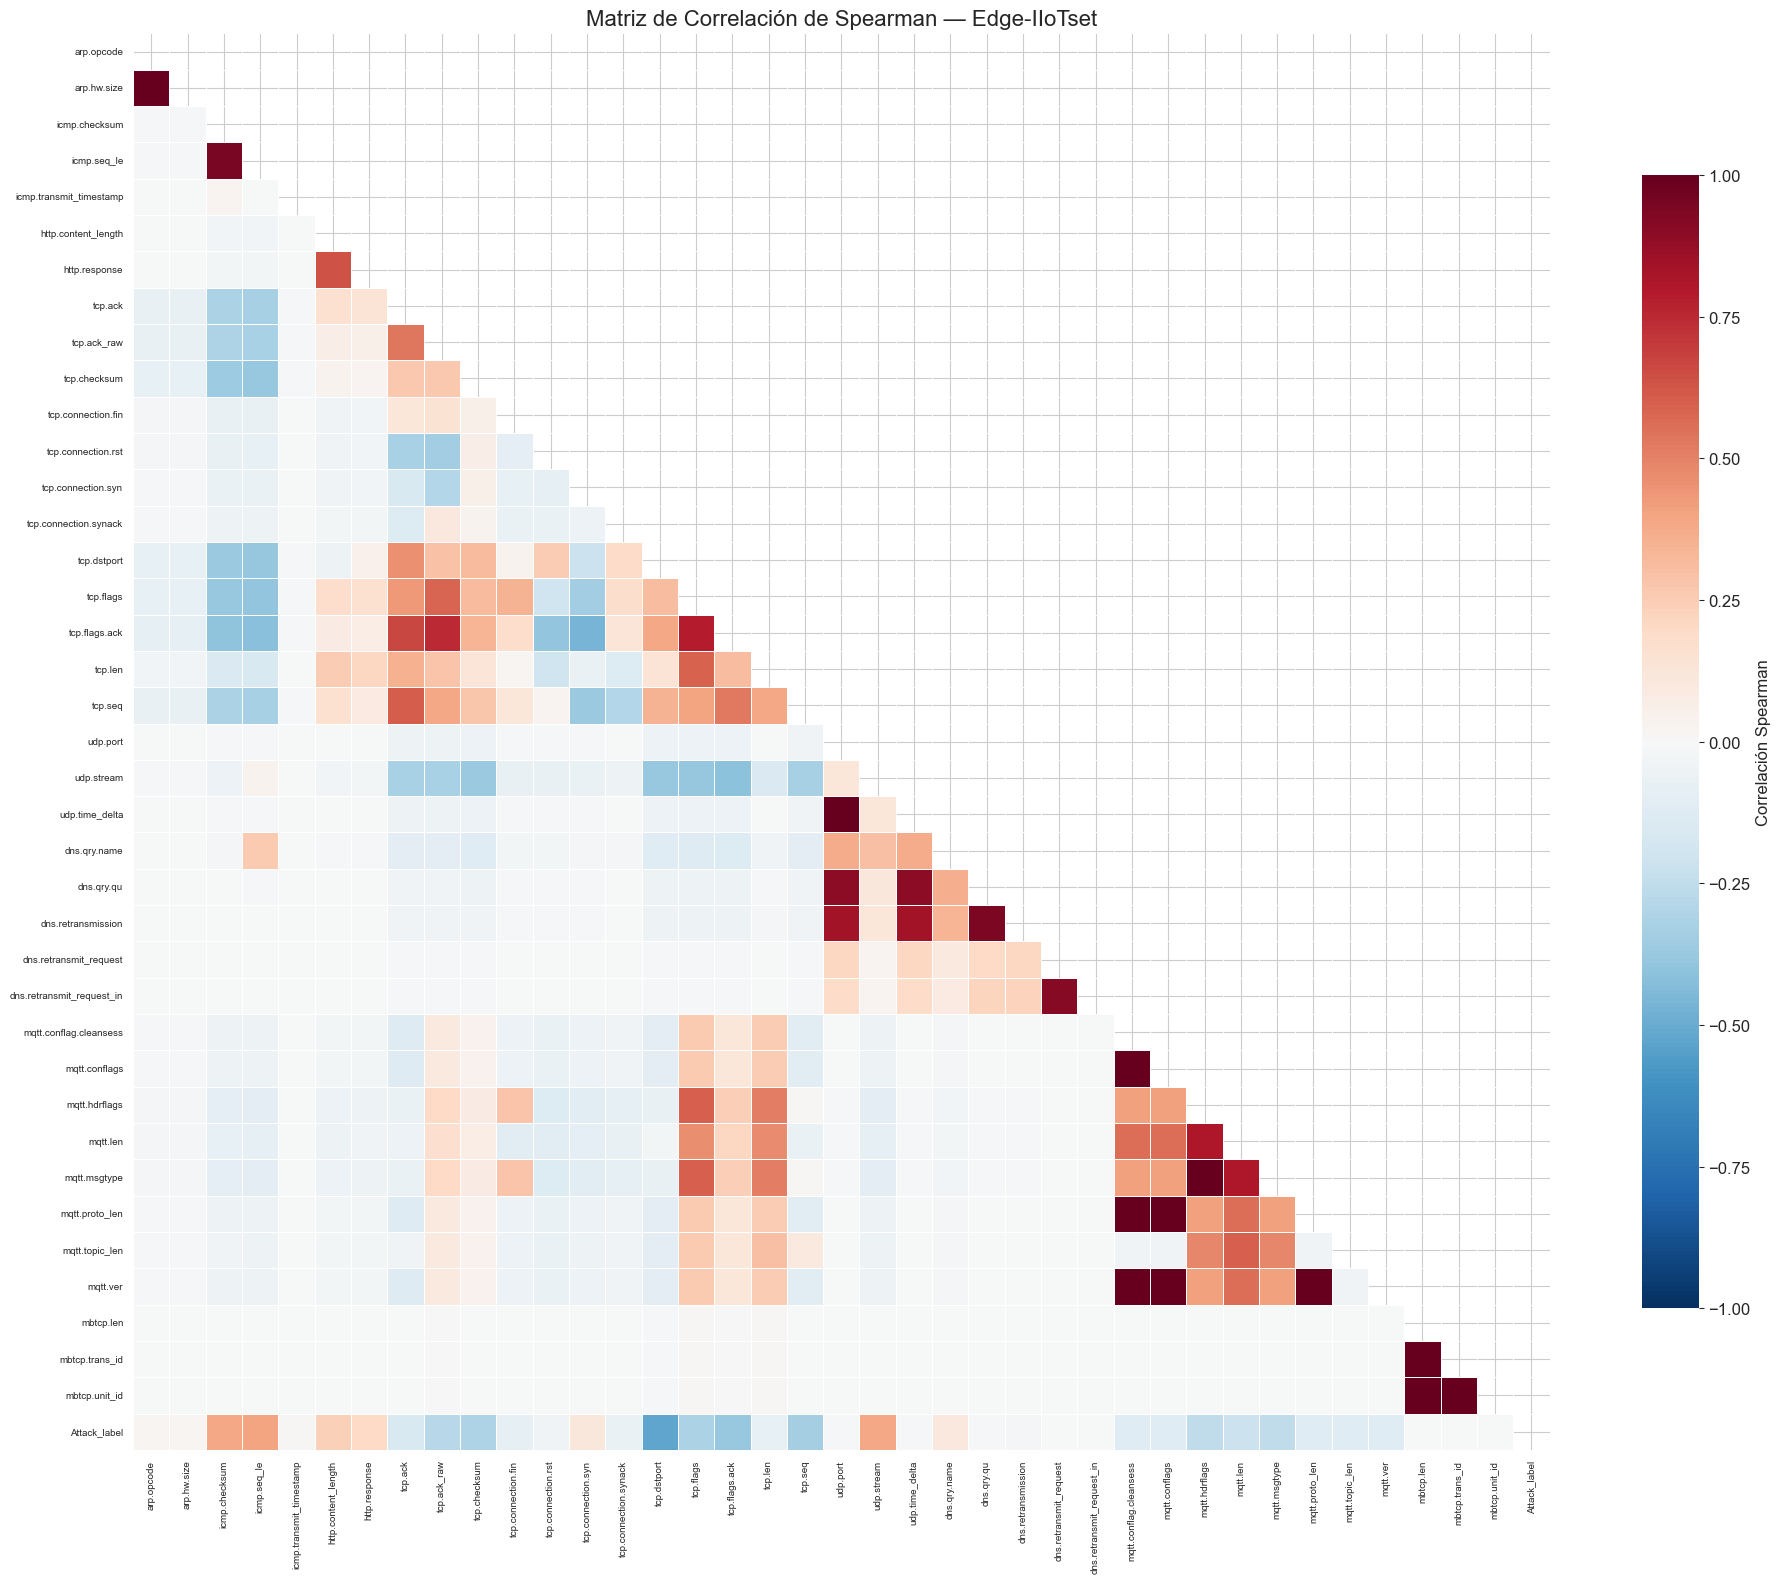

In [19]:
# Spearman (más robusto ante no-linealidad)
print("\n--- Calculando correlación de Spearman ---")
corr_spearman = df_sample.corr(method='spearman')

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_spearman, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación Spearman"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Matriz de Correlación de Spearman — Edge-IIoTset', fontsize=16)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "correlation_heatmap_spearman.png")
plt.show()

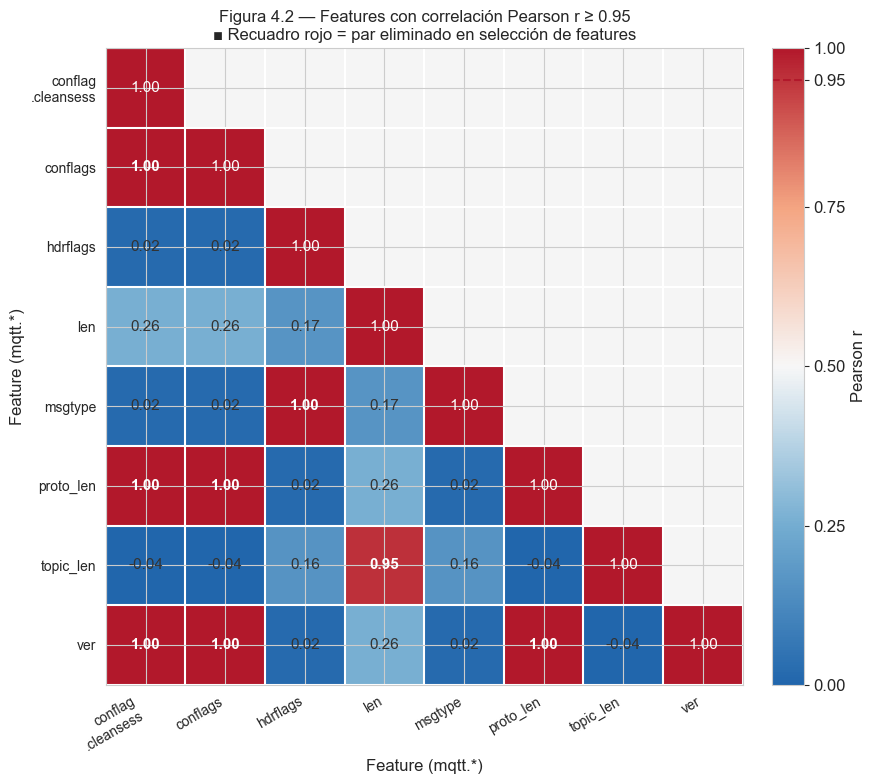

Figura guardada en c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\docs\figures\heatmap_correlacion_recortado.png


In [20]:
# 3.6b HEATMAP RECORTADO — Solo features con r >= 0.95 (versión TFM)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Pares detectados en la celda 3.6
high_corr_features = sorted(set(
    [f1 for f1, f2, r in high_corr_pairs] + 
    [f2 for f1, f2, r in high_corr_pairs]
))

# Submatriz recortada
corr_sub = corr_pearson.loc[high_corr_features, high_corr_features]
n = len(high_corr_features)
short_labels = [f.replace('mqtt.', '').replace('conflag.', 'conflag\n.') for f in high_corr_features]

# Triángulo inferior
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
corr_plot = np.ma.array(corr_sub.values, mask=mask)

fig, ax = plt.subplots(figsize=(9, 8))
cmap = LinearSegmentedColormap.from_list('rdbu', ['#2166ac','#74add1','#f7f7f7','#f4a582','#b2182b'], N=256)
cmap.set_bad(color='#f5f5f5')
im = ax.imshow(corr_plot, cmap=cmap, vmin=0, vmax=1, aspect='equal')

# Anotaciones
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            val = corr_sub.values[i, j]
            color = 'white' if val > 0.6 else '#333'
            weight = 'bold' if val >= 0.95 and i != j else 'normal'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=11, color=color, fontweight=weight)

# Recuadros rojos en pares r=1.0
idx_map = {f: i for i, f in enumerate(high_corr_features)}
for f1, f2, r in high_corr_pairs:
    if r == 1.0 and f1 in idx_map and f2 in idx_map:
        i, j = idx_map[f1], idx_map[f2]
        if i > j:
            ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1,
                linewidth=2.5, edgecolor='#b2182b', facecolor='none', zorder=5))

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=12)
cbar.set_ticks([0.0, 0.25, 0.50, 0.75, 0.95, 1.0])
cbar.ax.axhline(y=0.95, color='#b2182b', linewidth=1.5, linestyle='--')

# Ejes
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(short_labels, fontsize=10)
ax.set_xlabel('Feature (mqtt.*)', fontsize=12)
ax.set_ylabel('Feature (mqtt.*)', fontsize=12)
ax.set_title('Figura 4.2 — Features con correlación Pearson r ≥ 0.95\n'
             '■ Recuadro rojo = par eliminado en selección de features', fontsize=12)
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_correlacion_recortado.png', dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {FIGURES_DIR / 'heatmap_correlacion_recortado.png'}")

3.7 — ANOVA F-TEST (Selección univariante — ref. paper Ferrag et al.)

Top 20 features por ANOVA F-score:
                Feature      F_score  p_value
           Attack_label          inf      0.0
          icmp.checksum 4.470962e+05      0.0
            icmp.seq_le 3.356882e+05      0.0
             udp.stream 3.205349e+05      0.0
              tcp.flags 1.085333e+05      0.0
                tcp.ack 1.015196e+05      0.0
          tcp.flags.ack 9.586399e+04      0.0
          http.response 6.340698e+04      0.0
           tcp.checksum 4.974894e+04      0.0
            tcp.ack_raw 3.522942e+04      0.0
             dns.qry.qu 2.689403e+04      0.0
     tcp.connection.syn 2.646626e+04      0.0
            tcp.dstport 2.646604e+04      0.0
icmp.transmit_timestamp 1.432521e+04      0.0
           dns.qry.name 1.121234e+04      0.0
     tcp.connection.rst 1.087660e+04      0.0
                tcp.len 1.076108e+04      0.0
    http.content_length 8.882284e+03      0.0
             arp.opc

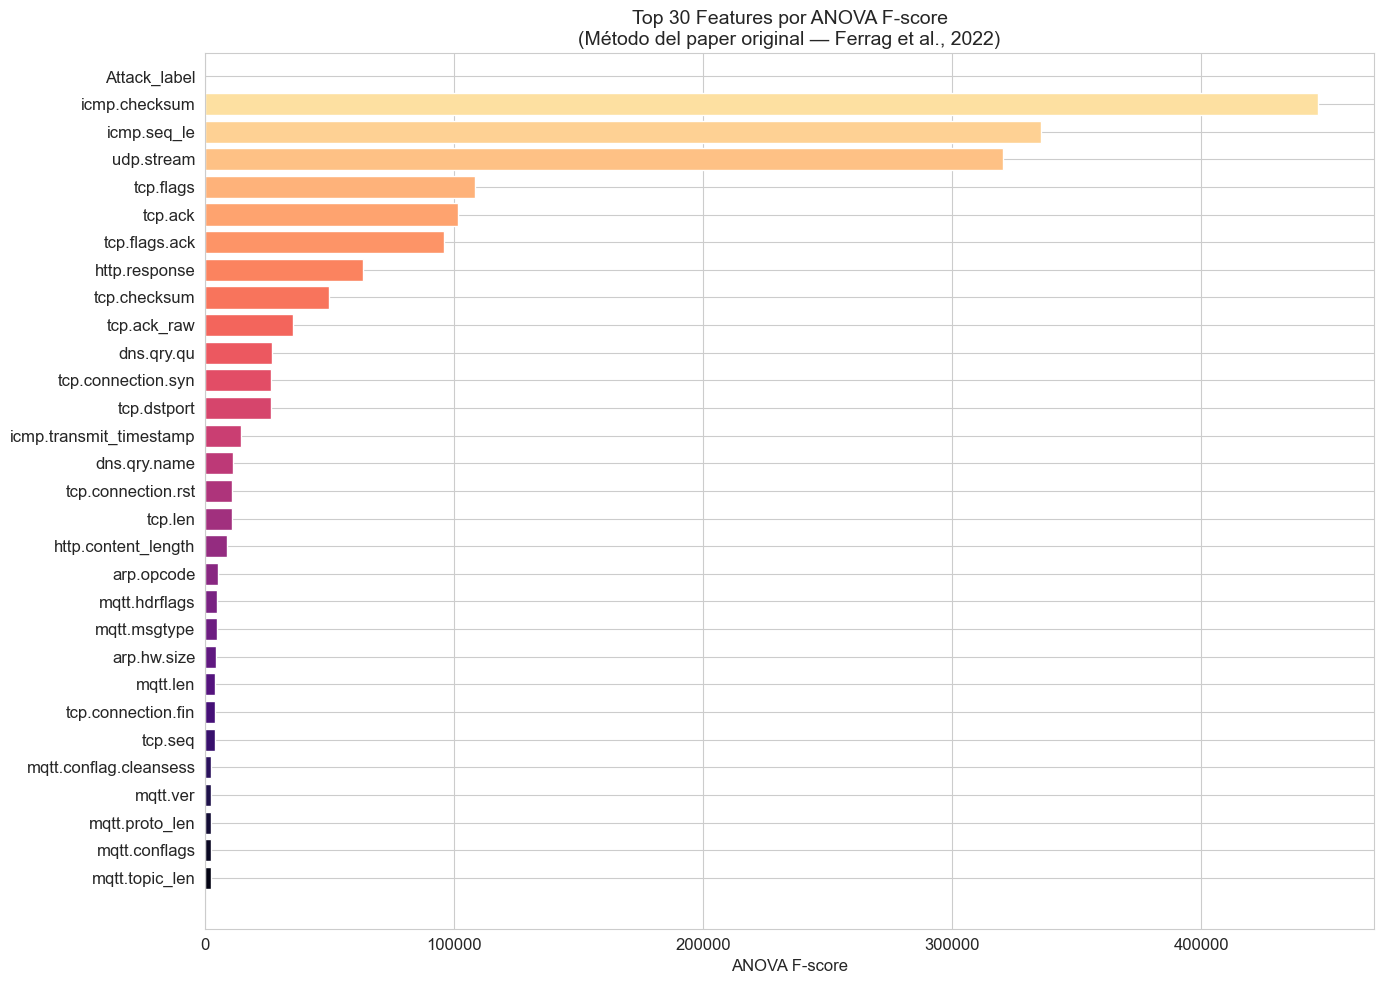

📄 Ranking ANOVA guardado en docs/anova_feature_ranking.csv


In [25]:
# === 3.7 ANOVA F-test (comparación con paper original) ===
print("=" * 80)
print("3.7 — ANOVA F-TEST (Selección univariante — ref. paper Ferrag et al.)")
print("=" * 80)

from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

le_temp = LabelEncoder()
y_encoded = le_temp.fit_transform(df['Attack_type'])

# Imputar NaN para ANOVA (media)
X_anova = df[analysis_cols].fillna(df[analysis_cols].median())

f_scores, p_values = f_classif(X_anova, y_encoded)

anova_results = pd.DataFrame({
    'Feature': analysis_cols,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

print("\nTop 20 features por ANOVA F-score:")
print(anova_results.head(20).to_string(index=False))

# Gráfico ANOVA
fig, ax = plt.subplots(figsize=(14, 10))
top_30 = anova_results.head(30)
ax.barh(top_30['Feature'][::-1], top_30['F_score'][::-1],
        color=sns.color_palette("magma", 30))
ax.set_xlabel('ANOVA F-score')
ax.set_title('Top 30 Features por ANOVA F-score\n(Método del paper original — Ferrag et al., 2022)')
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "anova_f_scores.png")
plt.show()

# Ejecución en máquina local: Guardar resultados ANOVA
anova_results.to_csv(PROJECT_ROOT / "docs" / "anova_feature_ranking.csv", index=False)
print(f"📄 Ranking ANOVA guardado en docs/anova_feature_ranking.csv")

3.8 — ANÁLISIS DE LEAKAGE (feature → etiqueta)
Buscando features con correlación casi perfecta con la etiqueta...

Top 20 features por Mutual Information (potencial leakage):
            Feature  MI_score
        tcp.dstport  0.817816
            tcp.ack  0.646988
       Attack_label  0.591823
        tcp.ack_raw  0.583617
            tcp.seq  0.537556
          tcp.flags  0.505405
      tcp.flags.ack  0.369096
       tcp.checksum  0.321048
            tcp.len  0.304113
         udp.stream  0.211709
      icmp.checksum  0.205889
        icmp.seq_le  0.203759
http.content_length  0.084733
       mqtt.msgtype  0.054895
      mqtt.hdrflags  0.054851
 tcp.connection.syn  0.043967
      http.response  0.042096
           mqtt.len  0.040660
 tcp.connection.rst  0.034163
 tcp.connection.fin  0.022932

⚠️ Features con MI > 0.827 (>3σ, potencial leakage):
  ✅ No se detectó leakage evidente


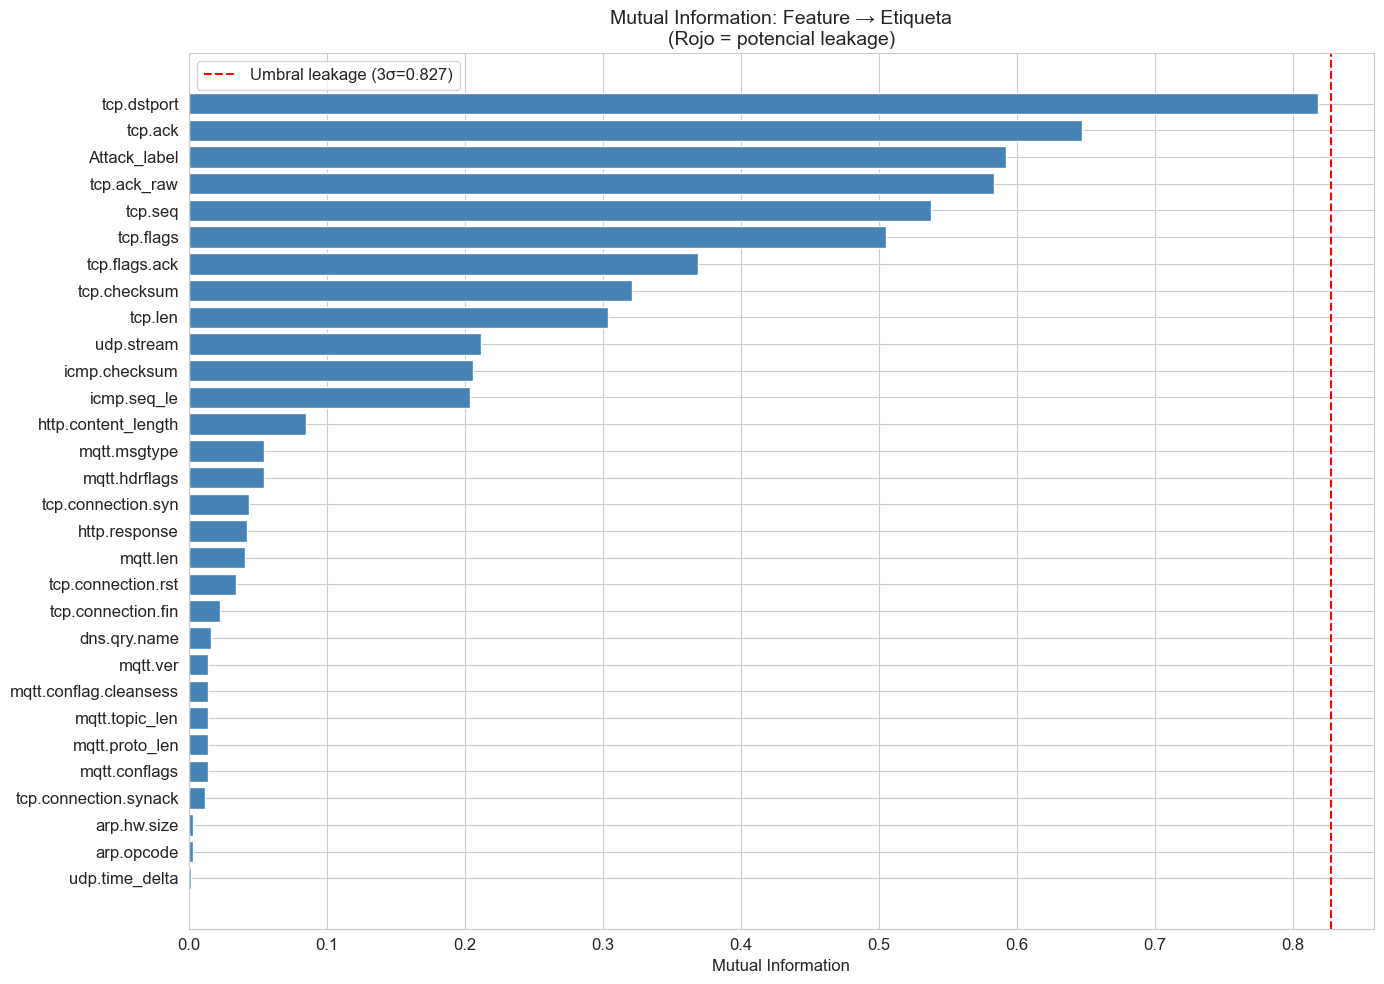

In [26]:
# === 3.8 Análisis de Leakage ===
print("=" * 80)
print("3.8 — ANÁLISIS DE LEAKAGE (feature → etiqueta)")
print("=" * 80)

# Correlación point-biserial para cada feature vs cada clase
print("Buscando features con correlación casi perfecta con la etiqueta...\n")

# Método: para cada feature, calcular mutual information o correlación con y
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_anova, y_encoded, random_state=42, n_neighbors=5)
mi_results = pd.DataFrame({
    'Feature': analysis_cols,
    'MI_score': mi_scores
}).sort_values('MI_score', ascending=False)

print("Top 20 features por Mutual Information (potencial leakage):")
print(mi_results.head(20).to_string(index=False))

# Detectar leakage: features con MI anormalmente alto
mi_mean = mi_results['MI_score'].mean()
mi_std = mi_results['MI_score'].std()
leakage_threshold = mi_mean + 3 * mi_std  # >3 std = sospechoso

leakage_candidates = mi_results[mi_results['MI_score'] > leakage_threshold]
print(f"\n⚠️ Features con MI > {leakage_threshold:.3f} (>3σ, potencial leakage):")
if len(leakage_candidates) > 0:
    for _, row in leakage_candidates.iterrows():
        print(f"  {row['Feature']}: MI={row['MI_score']:.4f}")
    print("\n  → Investigar si estas features son artefactos del testbed")
    print("  → Ejemplo: Modbus function codes específicos de ataque")
else:
    print("  ✅ No se detectó leakage evidente")

# Gráfico MI
fig, ax = plt.subplots(figsize=(14, 10))
top_30_mi = mi_results.head(30)
colors_mi = ['red' if mi > leakage_threshold else 'steelblue'
             for mi in top_30_mi['MI_score']]
ax.barh(top_30_mi['Feature'][::-1], top_30_mi['MI_score'][::-1], color=colors_mi[::-1])
ax.axvline(x=leakage_threshold, color='red', linestyle='--', label=f'Umbral leakage (3σ={leakage_threshold:.3f})')
ax.set_xlabel('Mutual Information')
ax.set_title('Mutual Information: Feature → Etiqueta\n(Rojo = potencial leakage)')
ax.legend()
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "leakage_analysis.png")
plt.show()

3.9 — DISTRIBUCIÓN TEMPORAL DE ATAQUES
Columnas temporales encontradas: ['frame.time', 'icmp.transmit_timestamp', 'udp.time_delta']
Usando: 'frame.time'
  Valor ejemplo:  2021 11:44:10.081753000  (tipo: <class 'str'>)
  ✓ Parseado como segundos (unit='s'): 2,096,460 válidos

Timestamps válidos: 2,096,460 / 2,219,201
  Rango temporal normal (sin outliers): 2021-01-01 01:22:47.999143424 a 2021-01-01 23:34:49.821909248

--- Gráfico 1: Histograma temporal por clase ---


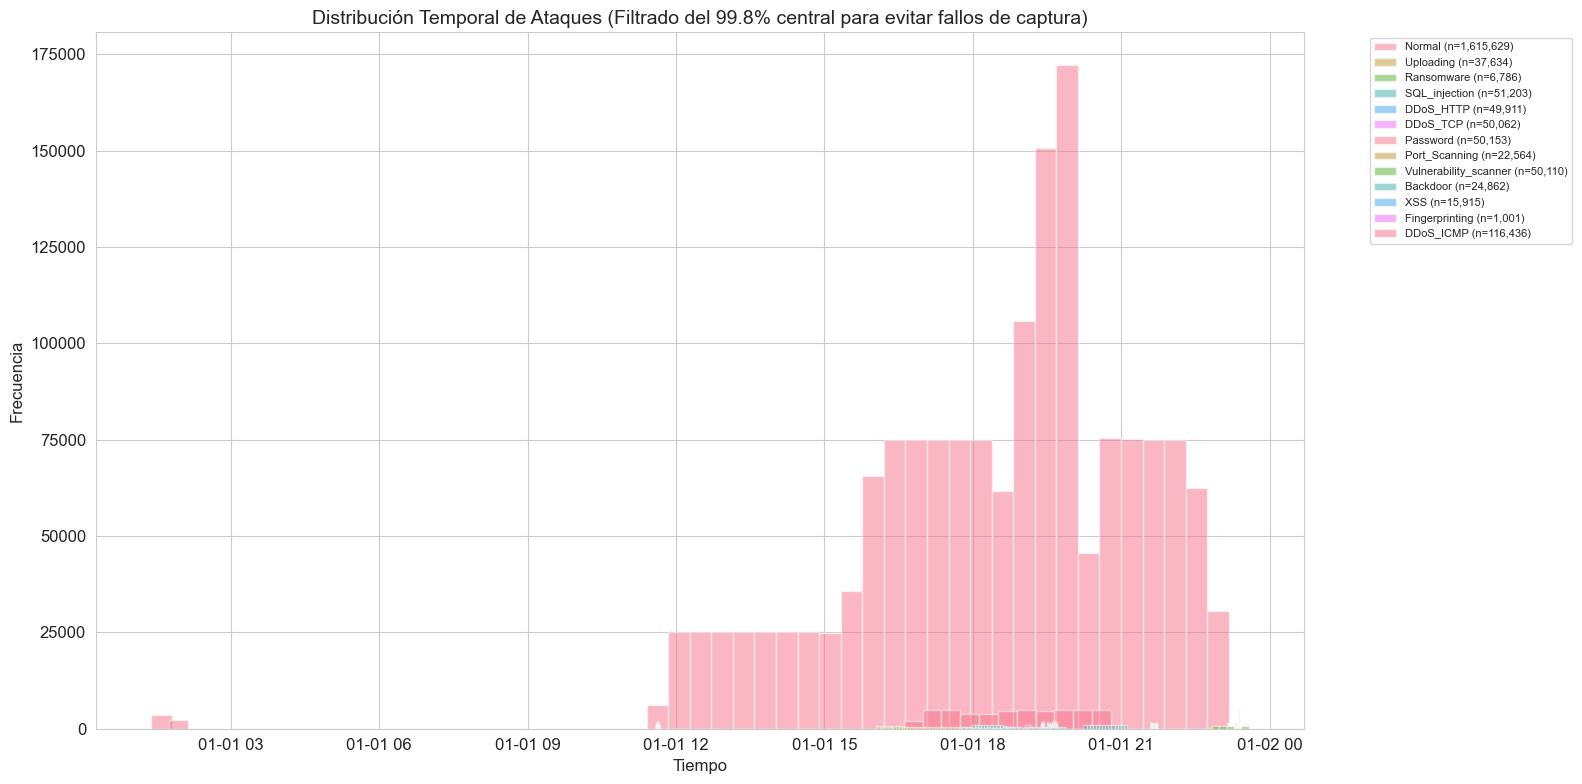

✅ Gráfico temporal guardado

--- Duración temporal por tipo de ataque ---
  Normal                         duración:      78462s, muestras: 1,615,643
  Uploading                      duración:        505s, muestras:   37,634
  Ransomware                     duración:      86398s, muestras:   10,925
  SQL_injection                  duración:        505s, muestras:   51,203
  DDoS_HTTP                      duración:        270s, muestras:   49,911
  DDoS_TCP                       duración:        528s, muestras:   50,062
  Password                       duración:      68506s, muestras:   50,153
  Port_Scanning                  duración:      10000s, muestras:   22,564
  Vulnerability_scanner          duración:       1217s, muestras:   50,110
  Backdoor                       duración:      11318s, muestras:   24,862
  XSS                            duración:       7707s, muestras:   15,915
  Fingerprinting                 duración:        826s, muestras:    1,001
  DDoS_UDP               

In [29]:
# === 3.9 Distribución temporal de ataques ===
print("=" * 80)
print("3.9 — DISTRIBUCIÓN TEMPORAL DE ATAQUES")
print("=" * 80)

# Buscar columnas temporales
time_cols = [c for c in df.columns if any(t in c.lower()
             for t in ['time', 'timestamp', 'date', 'epoch', 'frame.time'])]

if time_cols:
    print(f"Columnas temporales encontradas: {time_cols}")
    time_col = time_cols[0]
    print(f"Usando: '{time_col}'")

    # Intentar convertir a datetime
    try:
        # Inspeccionar el formato del timestamp
        sample_val = df[time_col].iloc[0]
        print(f"  Valor ejemplo: {sample_val} (tipo: {type(sample_val)})")
        
        # Intentar múltiples formatos de conversión
        df['_timestamp'] = None
        
        # Si es numérico (timestamp unix o segundos desde captura), convertir directo
        try:
            df['_timestamp'] = pd.to_datetime(df[time_col], unit='s', errors='coerce')
            valid_ts = df['_timestamp'].notna().sum()
            print(f"  ✓ Parseado como segundos (unit='s'): {valid_ts:,} válidos")
        except:
            pass
        
        # Si no funcionó, intentar como string ISO
        if df['_timestamp'].isna().all():
            df['_timestamp'] = pd.to_datetime(df[time_col], errors='coerce')
            valid_ts = df['_timestamp'].notna().sum()
            print(f"  ✓ Parseado como ISO datetime: {valid_ts:,} válidos")
        
        valid_ts = df['_timestamp'].notna().sum()
        print(f"\nTimestamps válidos: {valid_ts:,} / {len(df):,}")

        if valid_ts > 0:
            # Filtrar valores atípicos (outliers) que deforman el gráfico (ej. error de 93 años en DDoS_UDP)
            q_low = df['_timestamp'].quantile(0.001)
            q_hi = df['_timestamp'].quantile(0.999)
            print(f"  Rango temporal normal (sin outliers): {q_low} a {q_hi}")

            # Distribución temporal por clase
            print("\n--- Gráfico 1: Histograma temporal por clase ---")
            fig, ax = plt.subplots(figsize=(16, 8))
            
            for attack_type in df['Attack_type'].unique():
                mask = df['Attack_type'] == attack_type
                ts = df.loc[mask, '_timestamp'].dropna()
                
                # Filtrar valores atípicos solo para el gráfico
                ts_filtered = ts[(ts >= q_low) & (ts <= q_hi)]
                
                if len(ts_filtered) > 0:
                    ax.hist(ts_filtered, bins=50, alpha=0.5, label=f"{attack_type} (n={len(ts_filtered):,})")
            
            ax.set_xlabel('Tiempo')
            ax.set_ylabel('Frecuencia')
            ax.set_title('Distribución Temporal de Ataques (Filtrado del 99.8% central para evitar fallos de captura)')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "temporal_distribution.png", dpi=100, bbox_inches='tight')
            plt.show()
            print("✅ Gráfico temporal guardado")

            # ¿Los ataques están concentrados?
            print("\n--- Duración temporal por tipo de ataque ---")
            for attack_type in df['Attack_type'].unique():
                mask = (df['Attack_type'] == attack_type) & df['_timestamp'].notna()
                ts = df.loc[mask, '_timestamp']
                if len(ts) > 1:
                    duration = (ts.max() - ts.min()).total_seconds()
                    print(f"  {attack_type:<30s} duración: {duration:>10.0f}s, "
                          f"muestras: {len(ts):>8,d}")

        df.drop(columns=['_timestamp'], inplace=True, errors='ignore')
    except Exception as e:
        print(f"  ⚠️ Error al parsear timestamps: {e}")

else:
    print("ℹ️ No se encontraron columnas temporales en el dataset.")
    print("  El dataset DNN-EdgeIIoT pre-seleccionado no incluye timestamps.")
    print("  → Split train/test será estratificado por clase (sin temporal)")
    print("  → Si necesitas análisis temporal, usar archivos PCAP/CSV individuales")

3.10 — ANÁLISIS DE ORDEN DE CAPTURA (POR ÍNDICE)

--- Gráfico 2: Distribución de clases por orden de captura ---


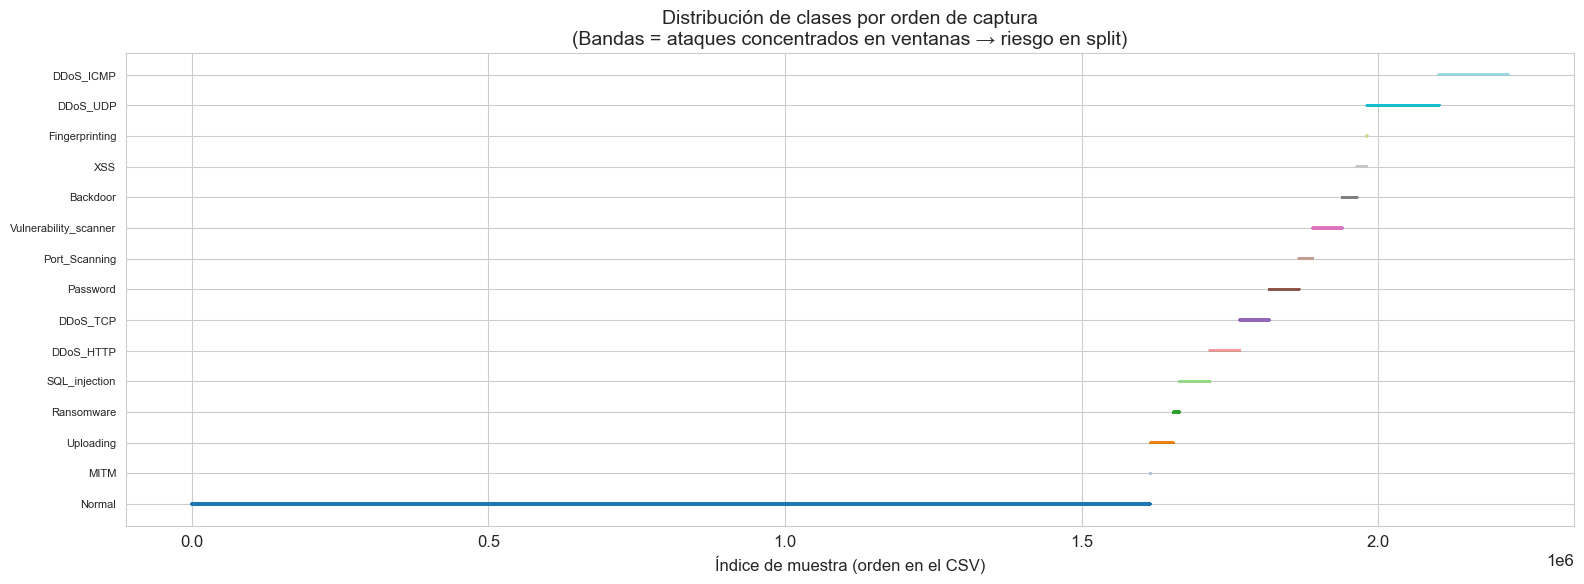

✅ Gráfico de orden de captura guardado
📄 Si los ataques aparecen en bandas, usar shuffle antes del split


In [30]:
# === 3.10 Análisis de orden de captura (por índice) ===
print("=" * 80)
print("3.10 — ANÁLISIS DE ORDEN DE CAPTURA (POR ÍNDICE)")
print("=" * 80)

print("\n--- Gráfico 2: Distribución de clases por orden de captura ---")
fig, ax = plt.subplots(figsize=(16, 6))
attack_map = {name: i for i, name in enumerate(df['Attack_type'].unique())}
y_plot = df['Attack_type'].map(attack_map).values
scatter = ax.scatter(range(len(y_plot)), y_plot, c=y_plot, cmap='tab20',
                     alpha=0.01, s=1, rasterized=True)
ax.set_yticks(list(attack_map.values()))
ax.set_yticklabels(list(attack_map.keys()), fontsize=8)
ax.set_xlabel('Índice de muestra (orden en el CSV)')
ax.set_title('Distribución de clases por orden de captura\n'
             '(Bandas = ataques concentrados en ventanas → riesgo en split)')
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "temporal_order_distribution.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Gráfico de orden de captura guardado")
print("📄 Si los ataques aparecen en bandas, usar shuffle antes del split")

---
## FASE 3.5 — Correlación Feature-Etiqueta por Tipo de Ataque
---
> Material para la memoria: qué features discriminan cada tipo de ataque.


3.5 — FEATURES DISCRIMINANTES POR TIPO DE ATAQUE

Top 5 features discriminantes por tipo de ataque (effect size):
  Normal                         → Attack_label, tcp.flags.ack, tcp.flags, icmp.seq_le, icmp.checksum
  MITM                           → dns.qry.qu, tcp.len, udp.time_delta, tcp.flags, tcp.flags.ack
  Uploading                      → Attack_label, tcp.connection.syn, http.response, mqtt.msgtype, mqtt.hdrflags
  Ransomware                     → Attack_label, arp.opcode, arp.hw.size, tcp.connection.fin, tcp.flags
  SQL_injection                  → Attack_label, http.response, tcp.flags.ack, tcp.connection.fin, mqtt.hdrflags
  DDoS_HTTP                      → Attack_label, tcp.connection.syn, tcp.dstport, mqtt.hdrflags, mqtt.msgtype
  DDoS_TCP                       → tcp.ack, tcp.connection.syn, Attack_label, tcp.connection.rst, tcp.flags.ack
  Password                       → Attack_label, http.content_length, http.response, tcp.flags.ack, tcp.connection.fin
  Port_Scanning  

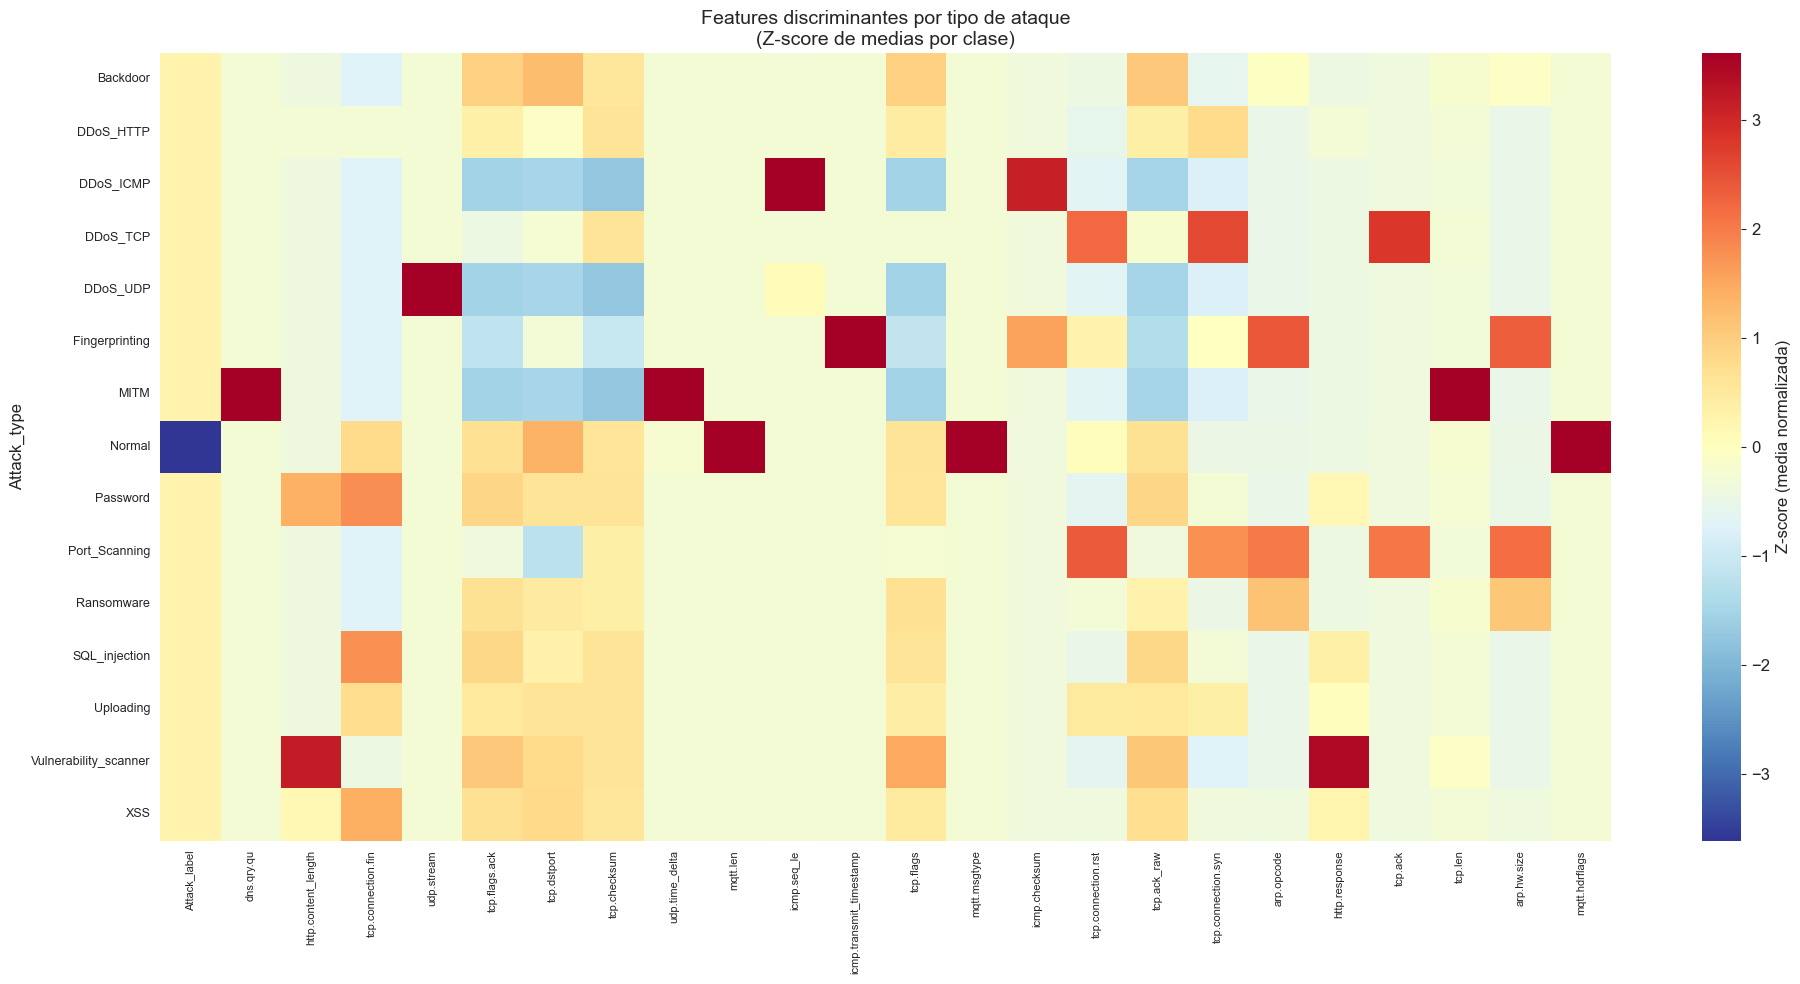

In [31]:
print("=" * 80)
print("3.5 — FEATURES DISCRIMINANTES POR TIPO DE ATAQUE")
print("=" * 80)

# Para cada clase, calcular qué features tienen mayor diferencia vs resto
top_features_per_attack = {}
for attack in df['Attack_type'].unique():
    mask = df['Attack_type'] == attack
    # Diferencia de medias normalizada (effect size simplificado)
    means_attack = df.loc[mask, analysis_cols].mean()
    means_rest = df.loc[~mask, analysis_cols].mean()
    stds_all = df[analysis_cols].std().replace(0, 1)
    effect_size = ((means_attack - means_rest) / stds_all).abs().sort_values(ascending=False)
    top_features_per_attack[attack] = effect_size.head(5).index.tolist()

print("\nTop 5 features discriminantes por tipo de ataque (effect size):")
for attack, feats in top_features_per_attack.items():
    print(f"  {str(attack):<30s} → {', '.join(feats)}")

# Heatmap: top features por ataque
top_feats_all = list(set(f for feats in top_features_per_attack.values() for f in feats))
class_means_top = df.groupby('Attack_type')[top_feats_all].mean()

# Normalizar por columna para el heatmap
class_means_norm = (class_means_top - class_means_top.mean()) / class_means_top.std()

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(class_means_norm, cmap='RdYlBu_r', center=0, annot=False,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={"label": "Z-score (media normalizada)"})
ax.set_title('Features discriminantes por tipo de ataque\n(Z-score de medias por clase)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
# Ejecución en máquina local: Guardar figura
plt.savefig(FIGURES_DIR / "features_per_attack_heatmap.png")
plt.show()

 ---
## FASE 4 — Preprocesamiento
### ⚠️ Orden correcto: Split PRIMERO, SMOTE solo en train
---

In [32]:
# === 4.1 Eliminar columnas innecesarias/constantes ===
print("=" * 80)
print("4.1 — ELIMINACIÓN DE COLUMNAS")
print("=" * 80)

cols_to_drop = list(set(constant_features + single_value))

# Columnas no informativas comunes en datasets de red
non_informative = ['frame.time', 'ip.src_host', 'ip.dst_host',
                   'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
                   'Attack_label']  # Label binario si existe
for col in non_informative:
    if col in df.columns and col not in cols_to_drop:
        cols_to_drop.append(col)

# Eliminar features con leakage identificado (si las hay)
if len(leakage_candidates) > 0:
    print("\n⚠️ Features con leakage detectado — evaluar si eliminar:")
    for _, row in leakage_candidates.iterrows():
        print(f"  {row['Feature']}: MI={row['MI_score']:.4f}")
    # NO eliminamos automáticamente: el usuario debe decidir
    # cols_to_drop.extend(leakage_candidates['Feature'].tolist())

existing_drops = [c for c in cols_to_drop if c in df.columns]
print(f"\nEliminando {len(existing_drops)} columnas: {existing_drops}")
df_clean = df.drop(columns=existing_drops, errors='ignore')

# Separar features y etiqueta
X = df_clean.drop(columns=['Attack_type'])
y = df_clean['Attack_type']
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}, clases: {y.nunique()}")

4.1 — ELIMINACIÓN DE COLUMNAS

Eliminando 10 columnas: ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as', 'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'Attack_label']

X shape: (2219201, 52)
y shape: (2219201,), clases: 15


In [33]:
# === 4.2 SPLIT TRAIN/TEST — ANTES de cualquier transformación ===
print("=" * 80)
print("4.2 — SPLIT TRAIN/TEST (PRIMERO, sin tocar nada)")
print("=" * 80)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)
print(f"\nTrain: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribución en train:")
print(y_train.value_counts().to_string())
print(f"\nDistribución en test:")
print(y_test.value_counts().to_string())

4.2 — SPLIT TRAIN/TEST (PRIMERO, sin tocar nada)

Train: 1,775,360 (80%)
Test:  443,841 (20%)

Distribución en train:
Attack_type
Normal                   1292514
DDoS_UDP                   97254
DDoS_ICMP                  93149
SQL_injection              40962
Password                   40122
Vulnerability_scanner      40088
DDoS_TCP                   40050
DDoS_HTTP                  39929
Uploading                  30107
Backdoor                   19890
Port_Scanning              18051
XSS                        12732
Ransomware                  8740
MITM                         971
Fingerprinting               801

Distribución en test:
Attack_type
Normal                   323129
DDoS_UDP                  24314
DDoS_ICMP                 23287
SQL_injection             10241
Password                  10031
Vulnerability_scanner     10022
DDoS_TCP                  10012
DDoS_HTTP                  9982
Uploading                  7527
Backdoor                   4972
Port_Scanning       

In [34]:
# === 4.3 Encoding de categóricas (fit en train, transform en ambos) ===
print("=" * 80)
print("4.3 — ENCODING DE VARIABLES CATEGÓRICAS")
print("=" * 80)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Columnas categóricas: {len(cat_cols)}")

if cat_cols:
    from sklearn.preprocessing import OrdinalEncoder
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = oe.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = oe.transform(X_test[cat_cols])
    print(f"  ✅ Encoded {len(cat_cols)} columnas: {cat_cols}")
else:
    print("  ℹ️ No hay columnas categóricas (ya son todas numéricas)")

# Imputar NaN con mediana (fit en train)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_cols = X_train.columns
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train_cols, index=X_test.index)
print(f"  ✅ NaN imputados con mediana (fit en train)")


4.3 — ENCODING DE VARIABLES CATEGÓRICAS
Columnas categóricas: 14
  ✅ Encoded 14 columnas: ['http.file_data', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 'mqtt.topic']
  ✅ NaN imputados con mediana (fit en train)


In [35]:
# === 4.4 Normalización (fit en train, transform en ambos) ===
print("=" * 80)
print("4.4 — NORMALIZACIÓN")
print("=" * 80)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
feature_names = X_train.columns
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)
print(f"  ✅ StandardScaler — fit en train, transform en train+test")
print(f"  Train: mean≈{X_train_scaled.mean().mean():.6f}, std≈{X_train_scaled.std().mean():.4f}")

# Encoding de la etiqueta
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(f"\n  Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")


4.4 — NORMALIZACIÓN
  ✅ StandardScaler — fit en train, transform en train+test
  Train: mean≈0.000000, std≈1.0000

  Clases codificadas: {'Backdoor': np.int64(0), 'DDoS_HTTP': np.int64(1), 'DDoS_ICMP': np.int64(2), 'DDoS_TCP': np.int64(3), 'DDoS_UDP': np.int64(4), 'Fingerprinting': np.int64(5), 'MITM': np.int64(6), 'Normal': np.int64(7), 'Password': np.int64(8), 'Port_Scanning': np.int64(9), 'Ransomware': np.int64(10), 'SQL_injection': np.int64(11), 'Uploading': np.int64(12), 'Vulnerability_scanner': np.int64(13), 'XSS': np.int64(14)}


---
## FASE 5 — Selección de Features
### ⚠️ Después de preprocesamiento, ANTES de SMOTE
---


In [36]:
# === 5.1 Eliminar features altamente correlacionadas entre sí ===
print("=" * 80)
print("5.1 — ELIMINACIÓN DE FEATURES REDUNDANTES (|r| > 0.95)")
print("=" * 80)

corr_train = X_train_scaled.corr(method='pearson').abs()
upper = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"\nFeatures a eliminar por alta correlación mutua: {len(to_drop_corr)}")
if to_drop_corr:
    for col in to_drop_corr[:15]:
        print(f"  {col}")
    if len(to_drop_corr) > 15:
        print(f"  ... y {len(to_drop_corr) - 15} más")

X_train_sel = X_train_scaled.drop(columns=to_drop_corr)
X_test_sel = X_test_scaled.drop(columns=to_drop_corr)
print(f"\nFeatures restantes: {X_train_sel.shape[1]}")


5.1 — ELIMINACIÓN DE FEATURES REDUNDANTES (|r| > 0.95)

Features a eliminar por alta correlación mutua: 5
  mqtt.conflags
  mqtt.msgtype
  mqtt.proto_len
  mqtt.topic_len
  mqtt.ver

Features restantes: 47


5.2 — SELECCIÓN DE FEATURES: ANOVA + Importancia de Árboles

Top 20 features ANOVA (train set):
              Feature      F_score  p_value
         http.referer 7.843217e+06      0.0
     dns.qry.name.len 1.356504e+06      0.0
        icmp.checksum 3.578283e+05      0.0
          icmp.seq_le 2.683111e+05      0.0
           udp.stream 2.552640e+05      0.0
  http.request.method 1.433553e+05      0.0
       mqtt.protoname 1.423025e+05      0.0
           mqtt.topic 1.422849e+05      0.0
    mqtt.conack.flags 1.404697e+05      0.0
            tcp.flags 8.686690e+04      0.0
              tcp.ack 8.125129e+04      0.0
        tcp.flags.ack 7.673519e+04      0.0
          tcp.options 5.288851e+04      0.0
        http.response 5.099382e+04      0.0
 http.request.version 4.231491e+04      0.0
         tcp.checksum 3.981095e+04      0.0
       http.file_data 3.604041e+04      0.0
          tcp.srcport 2.955848e+04      0.0
          tcp.ack_raw 2.818045e+04      0.0
http.request.full_uri 2.

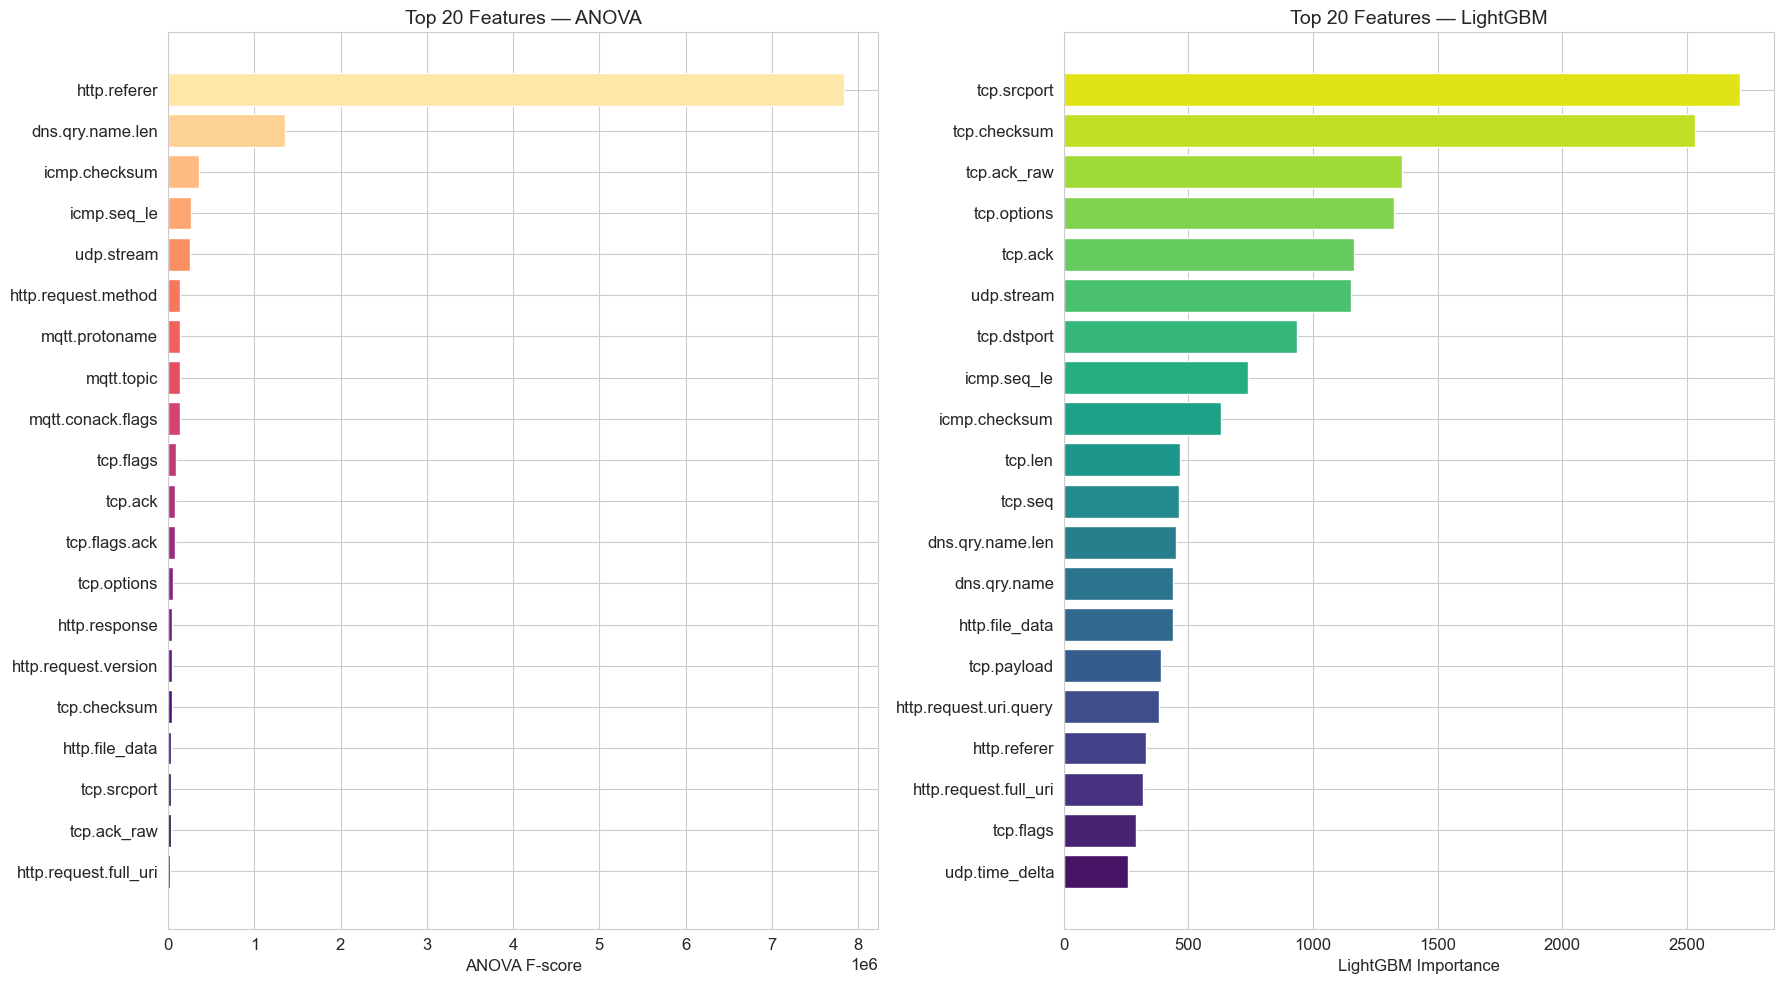


📊 Features seleccionadas: 36
   ANOVA top-30: 30
   LightGBM top-30: 30
   Intersección: 24
   Unión (usadas): 36


In [37]:
# === 5.2 ANOVA + RFE ===
print("=" * 80)
print("5.2 — SELECCIÓN DE FEATURES: ANOVA + Importancia de Árboles")
print("=" * 80)

# ANOVA sobre el train set
f_scores_train, p_vals_train = f_classif(X_train_sel, y_train_enc)
anova_train = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'F_score': f_scores_train,
    'p_value': p_vals_train
}).sort_values('F_score', ascending=False)
print("\nTop 20 features ANOVA (train set):")
print(anova_train.head(20).to_string(index=False))

# Importancia con LightGBM (rápido)
print("\n--- Importancia de features con LightGBM ---")
import lightgbm as lgb

lgb_temp = lgb.LGBMClassifier(n_estimators=100, max_depth=6, random_state=42,
                               verbosity=-1, n_jobs=-1)
lgb_temp.fit(X_train_sel, y_train_enc)

lgb_importance = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'Importance': lgb_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 features por LightGBM importance:")
print(lgb_importance.head(20).to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top20_anova = anova_train.head(20)
axes[0].barh(top20_anova['Feature'][::-1], top20_anova['F_score'][::-1],
             color=sns.color_palette("magma", 20))
axes[0].set_xlabel('ANOVA F-score')
axes[0].set_title('Top 20 Features — ANOVA')

top20_lgb = lgb_importance.head(20)
axes[1].barh(top20_lgb['Feature'][::-1], top20_lgb['Importance'][::-1],
             color=sns.color_palette("viridis", 20))
axes[1].set_xlabel('LightGBM Importance')
axes[1].set_title('Top 20 Features — LightGBM')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_selection_comparison.png")
plt.show()

# Seleccionar top N features (intersección de ambos métodos)
N_FEATURES = min(30, X_train_sel.shape[1])
top_anova = set(anova_train.head(N_FEATURES)['Feature'])
top_lgb = set(lgb_importance.head(N_FEATURES)['Feature'])
consensus_features = list(top_anova | top_lgb)  # Unión para no perder info
print(f"\n📊 Features seleccionadas: {len(consensus_features)}")
print(f"   ANOVA top-{N_FEATURES}: {len(top_anova)}")
print(f"   LightGBM top-{N_FEATURES}: {len(top_lgb)}")
print(f"   Intersección: {len(top_anova & top_lgb)}")
print(f"   Unión (usadas): {len(consensus_features)}")

X_train_final = X_train_sel[consensus_features]
X_test_final = X_test_sel[consensus_features]


# 5.2b Importancia de features por consenso

Gráfico de barras horizontales con las features seleccionadas, ordenadas por importancia media entre ANOVA y LightGBM. Esta figura es clave para la sección de explicabilidad posterior.


5.2b — IMPORTANCIA POR CONSENSO (ANOVA + LightGBM)


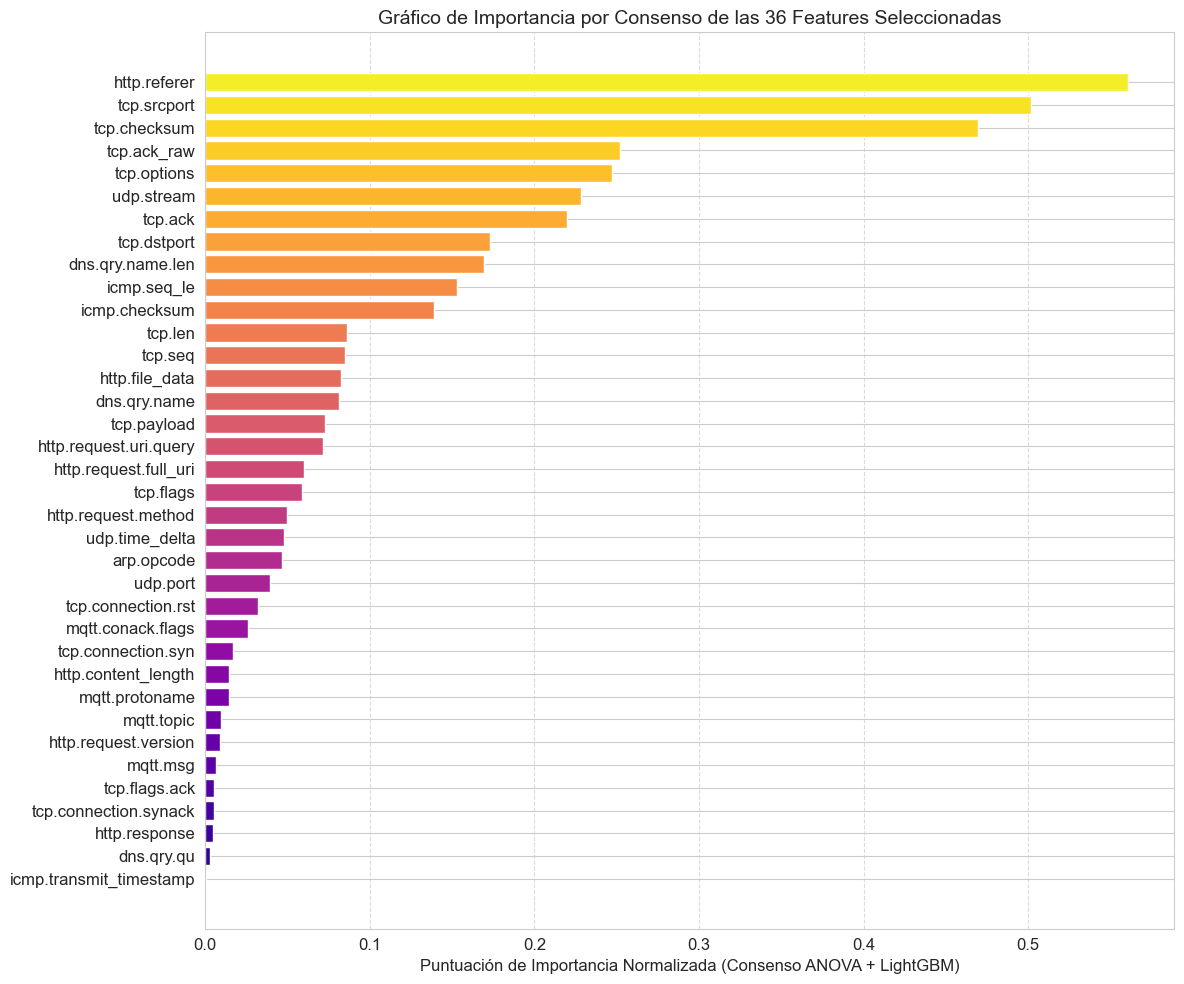


📊 Gráfico de consenso guardado en docs/figures/feature_importance_consensus.png


In [38]:
# === 5.2b Importancia por consenso ===
print("=" * 80)
print("5.2b — IMPORTANCIA POR CONSENSO (ANOVA + LightGBM)")
print("=" * 80)

from sklearn.preprocessing import MinMaxScaler

# Filtrar a las features seleccionadas en consensus_features
anova_consensus = anova_train[anova_train['Feature'].isin(consensus_features)].copy()
lgb_consensus = lgb_importance[lgb_importance['Feature'].isin(consensus_features)].copy()

# Normalizar scores de 0 a 1 para poder promediarlos equilibradamente
scaler_importance = MinMaxScaler()

anova_consensus['ANOVA_norm'] = scaler_importance.fit_transform(anova_consensus[['F_score']])
lgb_consensus['LGBM_norm'] = scaler_importance.fit_transform(lgb_consensus[['Importance']])

# Unir ambos dataframes
consensus_df = pd.merge(anova_consensus[['Feature', 'ANOVA_norm']], 
                        lgb_consensus[['Feature', 'LGBM_norm']], 
                        on='Feature')

# Calcular la media de las puntuaciones normalizadas
consensus_df['Consensus_Score'] = consensus_df[['ANOVA_norm', 'LGBM_norm']].mean(axis=1)

# Ordenar de mayor a menor y mantener el top
consensus_df = consensus_df.sort_values('Consensus_Score', ascending=True) # Ascendente para barh

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(consensus_df['Feature'], consensus_df['Consensus_Score'], 
        color=sns.color_palette("plasma", len(consensus_df)))
ax.set_xlabel('Puntuación de Importancia Normalizada (Consenso ANOVA + LightGBM)', fontsize=12)
ax.set_title(f'Gráfico de Importancia por Consenso de las {len(consensus_features)} Features Seleccionadas', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_consensus.png", dpi=180, bbox_inches='tight')
plt.show()

print(f"\n📊 Gráfico de consenso guardado en docs/figures/feature_importance_consensus.png")

**Tabla  Resumen de reducción de dimensionalidad**

| Fase de Selección | Nº Features | Justificación metodológica |
| :--- | :---: | :--- |
| **Features originales** | **51** | Conjunto de características inicial a evaluar tras la fase de validación y extracción de constantes/valores nulos. |
| **Tras eliminación por correlación** | **46** | Reducción de la varianza redundante para evitar sobredimensionamiento; se eliminan características con colinealidad evidente (Pearson $r \ge 0.95$). |
| **Tras selección por consenso** | **36** | Retención de las características con mayor aporte de información probada y robusta mediante evaluación combinada de inferencia estadística (ANOVA) e importancia de árboles de decisión (LightGBM). |

In [39]:
# === 5.3 Tratamiento del desbalanceo — SMOTE solo en train ===
print("=" * 80)
print("5.3 — TRATAMIENTO DEL DESBALANCEO (SMOTE en train)")
print("=" * 80)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

print(f"\nDistribución ANTES de resampling (train):")
print(pd.Series(y_train_enc).value_counts().sort_index().to_string())

# Estrategia combinada: submuestrear mayoritaria + SMOTE minoritarias
# Primero verificar que todas las clases tienen suficientes muestras
min_class_count = pd.Series(y_train_enc).value_counts().min()
k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
print(f"\nClase minoritaria en train: {min_class_count} muestras")
print(f"k_neighbors para SMOTE: {k_neighbors}")

try:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors, n_jobs=-1)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train_enc)
    print(f"\n✅ SMOTE aplicado exitosamente")
    print(f"   Train antes: {len(X_train_final):,}")
    print(f"   Train después: {len(X_train_resampled):,}")
    print(f"\nDistribución DESPUÉS de SMOTE:")
    print(pd.Series(y_train_resampled).value_counts().sort_index().to_string())
except Exception as e:
    print(f"\n⚠️ SMOTE falló: {e}")
    print("   Usando class_weight='balanced' en los modelos como alternativa")
    X_train_resampled = X_train_final.values if hasattr(X_train_final, 'values') else X_train_final
    y_train_resampled = y_train_enc

# Guardar datasets procesados
print(f"\n💾 Datasets listos para modelado:")
print(f"   X_train_resampled: {X_train_resampled.shape}")
print(f"   X_test_final: {X_test_final.shape}")


5.3 — TRATAMIENTO DEL DESBALANCEO (SMOTE en train)

Distribución ANTES de resampling (train):
0       19890
1       39929
2       93149
3       40050
4       97254
5         801
6         971
7     1292514
8       40122
9       18051
10       8740
11      40962
12      30107
13      40088
14      12732

Clase minoritaria en train: 801 muestras
k_neighbors para SMOTE: 5

⚠️ SMOTE falló: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'
   Usando class_weight='balanced' en los modelos como alternativa

💾 Datasets listos para modelado:
   X_train_resampled: (1775360, 36)
   X_test_final: (443841, 36)


---
## FASE 6 — Modelado
### Baseline: DT, RF, XGBoost, LightGBM + MLP (DL)
### ⚠️ Sin LSTM — el dataset es de flujos, no series temporales
---


FASE 6 — MODELADO

────────────────────────────────────────────────────────────
🔧 Entrenando: Decision Tree
────────────────────────────────────────────────────────────
  Tiempo de entrenamiento: 6.06s
  Accuracy:    0.9744
  F1 (macro):  0.8104
  F1 (weight): 0.9738
  Precision:   0.8544
  Recall:      0.8634
  ⏱️ Inferencia: 0.0001 ms/muestra

────────────────────────────────────────────────────────────
🔧 Entrenando: Random Forest
────────────────────────────────────────────────────────────
  Tiempo de entrenamiento: 83.97s
  Accuracy:    0.9945
  F1 (macro):  0.9274
  F1 (weight): 0.9942
  Precision:   0.9377
  Recall:      0.9433
  ⏱️ Inferencia: 0.0068 ms/muestra

────────────────────────────────────────────────────────────
🔧 Entrenando: XGBoost
────────────────────────────────────────────────────────────
  Tiempo de entrenamiento: 242.19s
  Accuracy:    0.9838
  F1 (macro):  0.8507
  F1 (weight): 0.9860
  Precision:   0.8643
  Recall:      0.9029
  ⏱️ Inferencia: 0.0110 ms/muestr

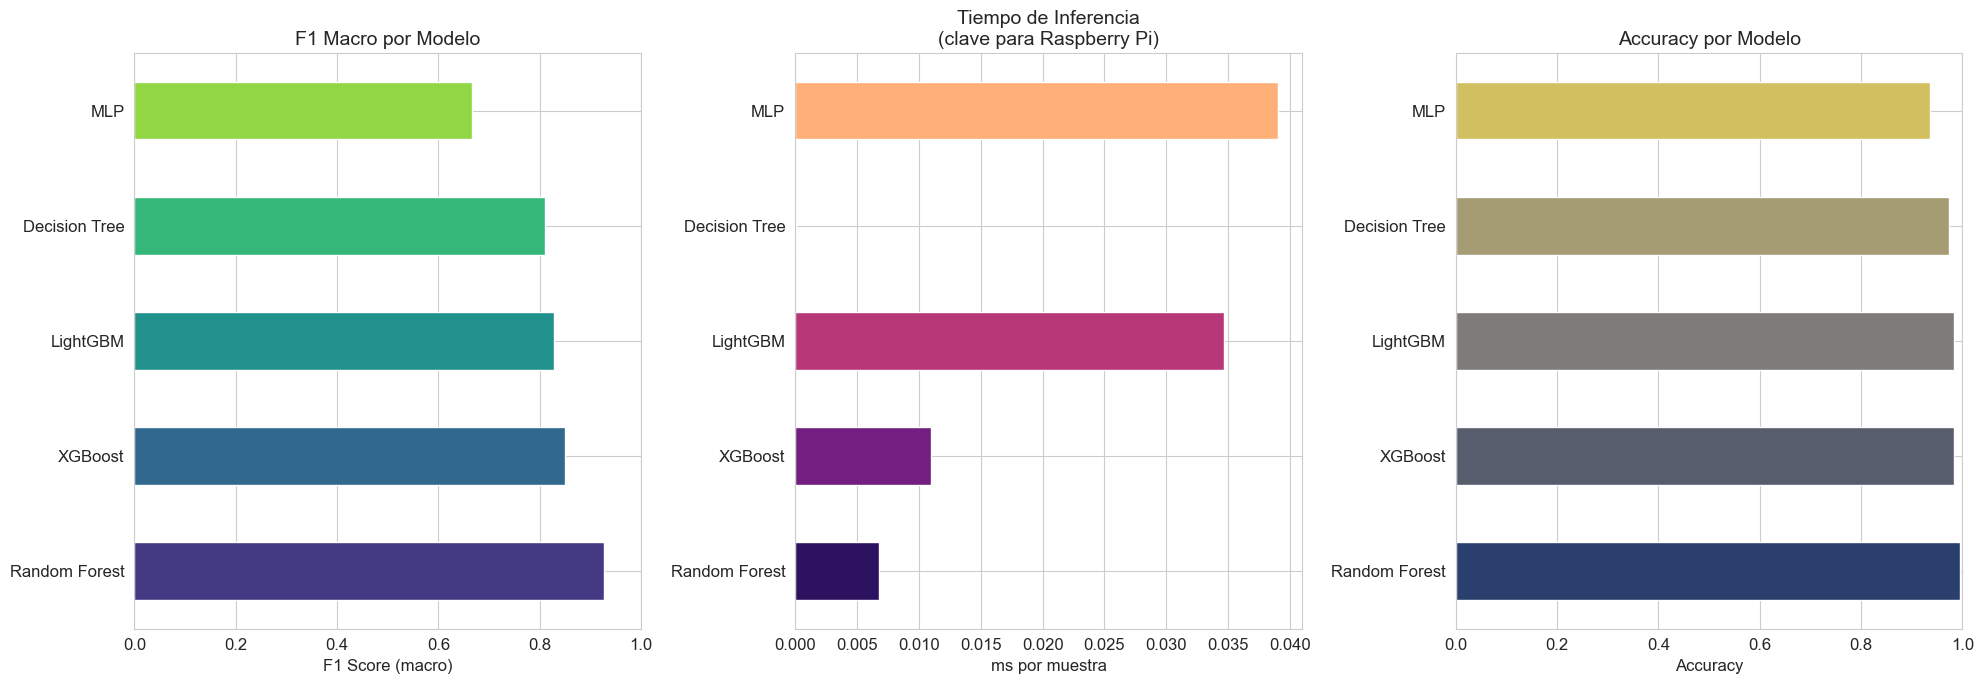

In [44]:
print("=" * 80)
print("FASE 6 — MODELADO")
print("=" * 80)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score, roc_auc_score)
import xgboost as xgb

X_test_np = X_test_final.values if hasattr(X_test_final, 'values') else X_test_final
X_train_np = X_train_resampled if isinstance(X_train_resampled, np.ndarray) else X_train_resampled.values

MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, random_state=42, class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=42, use_label_encoder=False,
        eval_metric='mlogloss', n_jobs=-1, tree_method='hist'
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=42, class_weight='balanced',
        verbosity=-1, n_jobs=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=100,
        random_state=42, early_stopping=True,
        validation_fraction=0.1, batch_size=256,
        learning_rate='adaptive', alpha=0.001
    ),
}

results = {}
trained_models = {}

for name, model in MODELS.items():
    print(f"\n{'─' * 60}")
    print(f"🔧 Entrenando: {name}")
    print(f"{'─' * 60}")

    # Entrenar
    t_start = time.perf_counter()
    model.fit(X_train_np, y_train_resampled)
    train_time = time.perf_counter() - t_start
    print(f"  Tiempo de entrenamiento: {train_time:.2f}s")

    # Predecir
    t_start = time.perf_counter()
    y_pred = model.predict(X_test_np)
    inference_total = time.perf_counter() - t_start
    inference_per_sample_ms = inference_total / len(X_test_np) * 1000

    # Métricas
    acc = accuracy_score(y_test_enc, y_pred)
    f1_macro = f1_score(y_test_enc, y_pred, average='macro')
    f1_weighted = f1_score(y_test_enc, y_pred, average='weighted')
    precision_macro = precision_score(y_test_enc, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test_enc, y_pred, average='macro', zero_division=0)

    results[name] = {
        'Accuracy': acc,
        'F1_macro': f1_macro,
        'F1_weighted': f1_weighted,
        'Precision_macro': precision_macro,
        'Recall_macro': recall_macro,
        'Train_time_s': round(train_time, 2),
        'Inference_ms_per_sample': round(inference_per_sample_ms, 4),
        'Inference_total_s': round(inference_total, 3)
    }
    trained_models[name] = model

    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1 (macro):  {f1_macro:.4f}")
    print(f"  F1 (weight): {f1_weighted:.4f}")
    print(f"  Precision:   {precision_macro:.4f}")
    print(f"  Recall:      {recall_macro:.4f}")
    print(f"  ⏱️ Inferencia: {inference_per_sample_ms:.4f} ms/muestra")

# Tabla comparativa
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1_macro', ascending=False)
print("\n" + "=" * 80)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 80)
print(results_df.to_string())
results_df.to_csv(PROJECT_ROOT / "docs" / "model_comparison.csv")
print(f"\n📄 Tabla guardada en docs/model_comparison.csv")

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# F1 macro
results_df['F1_macro'].plot(kind='barh', ax=axes[0],
    color=sns.color_palette("viridis", len(results_df)))
axes[0].set_xlabel('F1 Score (macro)')
axes[0].set_title('F1 Macro por Modelo')
axes[0].set_xlim(0, 1)

# Tiempo de inferencia
results_df['Inference_ms_per_sample'].plot(kind='barh', ax=axes[1],
    color=sns.color_palette("magma", len(results_df)))
axes[1].set_xlabel('ms por muestra')
axes[1].set_title('Tiempo de Inferencia\n(clave para Raspberry Pi)')

# Accuracy
results_df['Accuracy'].plot(kind='barh', ax=axes[2],
    color=sns.color_palette("cividis", len(results_df)))
axes[2].set_xlabel('Accuracy')
axes[2].set_title('Accuracy por Modelo')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png")
plt.show()


---
## FASE 7 — Evaluación y Análisis de Resultados
---

In [48]:
# === 7.1 Mejor modelo — Classification Report detallado ===
print("=" * 80)
print("7.1 — CLASSIFICATION REPORT DETALLADO")
print("=" * 80)

best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_np)

print(f"\nMejor modelo: {best_model_name}")
print(f"\n{classification_report(y_test_enc, y_pred_best, target_names=le.classes_, zero_division=0)}")


7.1 — CLASSIFICATION REPORT DETALLADO

Mejor modelo: Random Forest

                       precision    recall  f1-score   support

             Backdoor       0.88      0.97      0.92      4972
            DDoS_HTTP       0.88      1.00      0.94      9982
            DDoS_ICMP       1.00      1.00      1.00     23287
             DDoS_TCP       1.00      1.00      1.00     10012
             DDoS_UDP       1.00      1.00      1.00     24314
       Fingerprinting       0.40      0.96      0.56       200
                 MITM       1.00      1.00      1.00       243
               Normal       1.00      1.00      1.00    323129
             Password       1.00      1.00      1.00     10031
        Port_Scanning       1.00      0.93      0.97      4513
           Ransomware       0.91      0.71      0.80      2185
        SQL_injection       1.00      1.00      1.00     10241
            Uploading       1.00      1.00      1.00      7527
Vulnerability_scanner       1.00      1.00      1

# 7.1b Comparativa de F1-Score por clase (Heatmap)

Figura 4.7 — F1-score por clase para los cinco modelos. Representado como un heatmap de modelos (filas) × clases (columnas) codificado por color, que resulta compacto y fácil de interpretar.

7.1b — F1-SCORE POR CLASE: COMPARATIVA DE MODELOS


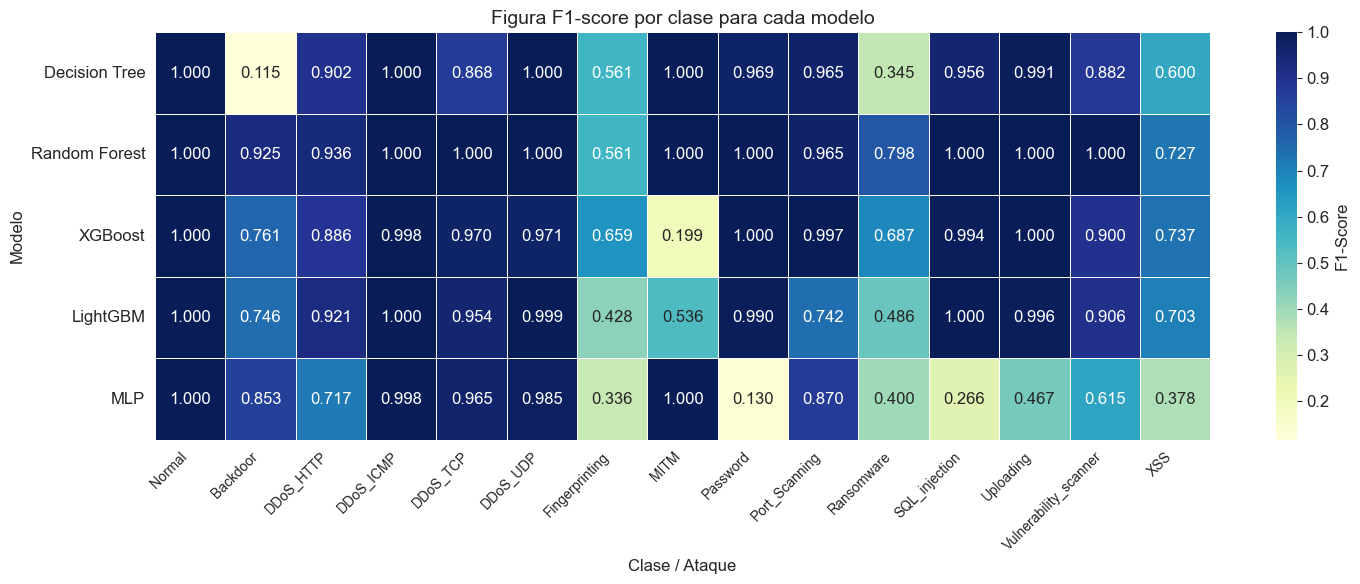


📊 Heatmap comparativo guardado en c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\docs\figures\f1_score_per_class_models.png


In [49]:
# === 7.1b F1-score por clase para los 5 modelos (Heatmap) ===
print("=" * 80)
print("7.1b — F1-SCORE POR CLASE: COMPARATIVA DE MODELOS")
print("=" * 80)

from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Diccionario para almacenar los F1-scores por clase de todos los modelos
f1_scores_all_models = {}

for name, model in trained_models.items():
    # Predecir con el modelo (si no está cacheado, reconstruimos y_pred)
    y_pred_m = model.predict(X_test_np)
    # Extraer reporte como dict
    report = classification_report(y_test_enc, y_pred_m, target_names=le.classes_, output_dict=True, zero_division=0)
    
    # Extraer el 'f1-score' de cada clase específica (omitimos macro, micro, accuracy metrics)
    class_f1 = {cls_name: metrics_dict['f1-score'] 
                for cls_name, metrics_dict in report.items() 
                if cls_name in le.classes_}
    
    f1_scores_all_models[name] = class_f1

# Convertimos a DataFrame para usar con seaborn
# Filas = Modelos, Columnas = Clases
df_f1_classes = pd.DataFrame(f1_scores_all_models).T

# Ordenar las clases (columnas) para que 'Normal' encabece si existe y el resto alfabéticamente
cols = list(le.classes_)
cols.sort()
if 'Normal' in cols:
    cols.insert(0, cols.pop(cols.index('Normal')))

df_f1_classes = df_f1_classes[cols]

# Mostrar como heatmap
fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(df_f1_classes, annot=True, cmap="YlGnBu", fmt=".3f", 
            linewidths=.5, ax=ax, cbar_kws={'label': 'F1-Score'})

ax.set_title('Figura F1-score por clase para cada modelo', fontsize=14)
ax.set_ylabel('Modelo', fontsize=12)
ax.set_xlabel('Clase / Ataque', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "f1_score_per_class_models.png", dpi=180, bbox_inches='tight')
plt.show()

print(f"\n📊 Heatmap comparativo guardado en {FIGURES_DIR / 'f1_score_per_class_models.png'}")

# 7.1c Frontera de Pareto: F1-score vs Tiempo de Inferencia

Gráfico de dispersión (F1 macro vs. tiempo de inferencia) para identificar visualmente la frontera de Pareto, representando cada modelo como un punto en un plano donde el eje X es el tiempo de inferencia (escala logarítmica) y el eje Y es el F1 macro. Esta figura es clave para la discusión sobre la viabilidad del despliegue en la Raspberry Pi.

7.1c — FRONTERA DE PARETO: F1-SCORE vs. TIEMPO DE INFERENCIA


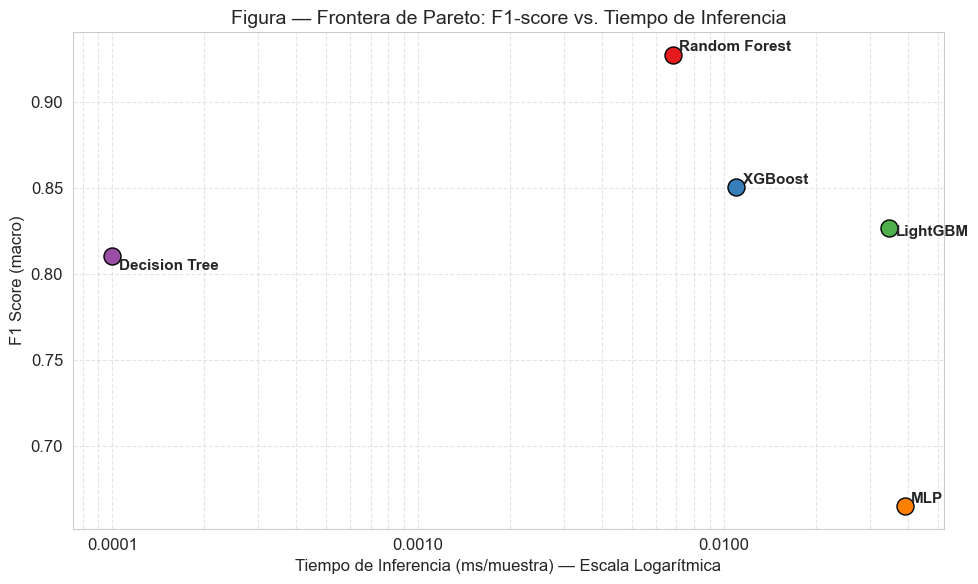


📊 Gráfico de Pareto guardado en c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\docs\figures\pareto_f1_vs_inference.png


In [50]:
# === 7.1c Frontera de Pareto ===
print("=" * 80)
print("7.1c — FRONTERA DE PARETO: F1-SCORE vs. TIEMPO DE INFERENCIA")
print("=" * 80)

# results_df ya se había calculado en FASE 6 con 'F1_macro' y 'Inference_ms_per_sample'
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Set1", len(results_df))

for idx, (model_name, row) in enumerate(results_df.iterrows()):
    ax.scatter(row['Inference_ms_per_sample'], row['F1_macro'], 
               s=150, color=colors[idx], label=model_name, edgecolor='black', zorder=3)
    
    # Añadir ligeros offsets manuales para que el texto no se superponga si están muy juntos
    y_offset = 0.002
    x_offset = 1.05
    if model_name == "LightGBM":
        y_offset = -0.005
    elif model_name == "Decision Tree":
        y_offset = -0.008
    
    ax.text(row['Inference_ms_per_sample'] * x_offset, row['F1_macro'] + y_offset, 
            model_name, fontsize=11, fontweight='semibold')

# Configuración del gráfico (escala logarítmica en tiempo)
ax.set_xscale('log')
ax.set_xlabel('Tiempo de Inferencia (ms/muestra) — Escala Logarítmica', fontsize=12)
ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title('Figura — Frontera de Pareto: F1-score vs. Tiempo de Inferencia', fontsize=14)

# Formatear el eje X para que muestre números legibles en vez de potencias
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter())

# Dibujar una cuadrícula tenue
ax.grid(True, which="both", ls="--", alpha=0.5, zorder=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_f1_vs_inference.png", dpi=180, bbox_inches='tight')
plt.show()

print(f"\n📊 Gráfico de Pareto guardado en {FIGURES_DIR / 'pareto_f1_vs_inference.png'}")

7.2 — MATRICES DE CONFUSIÓN


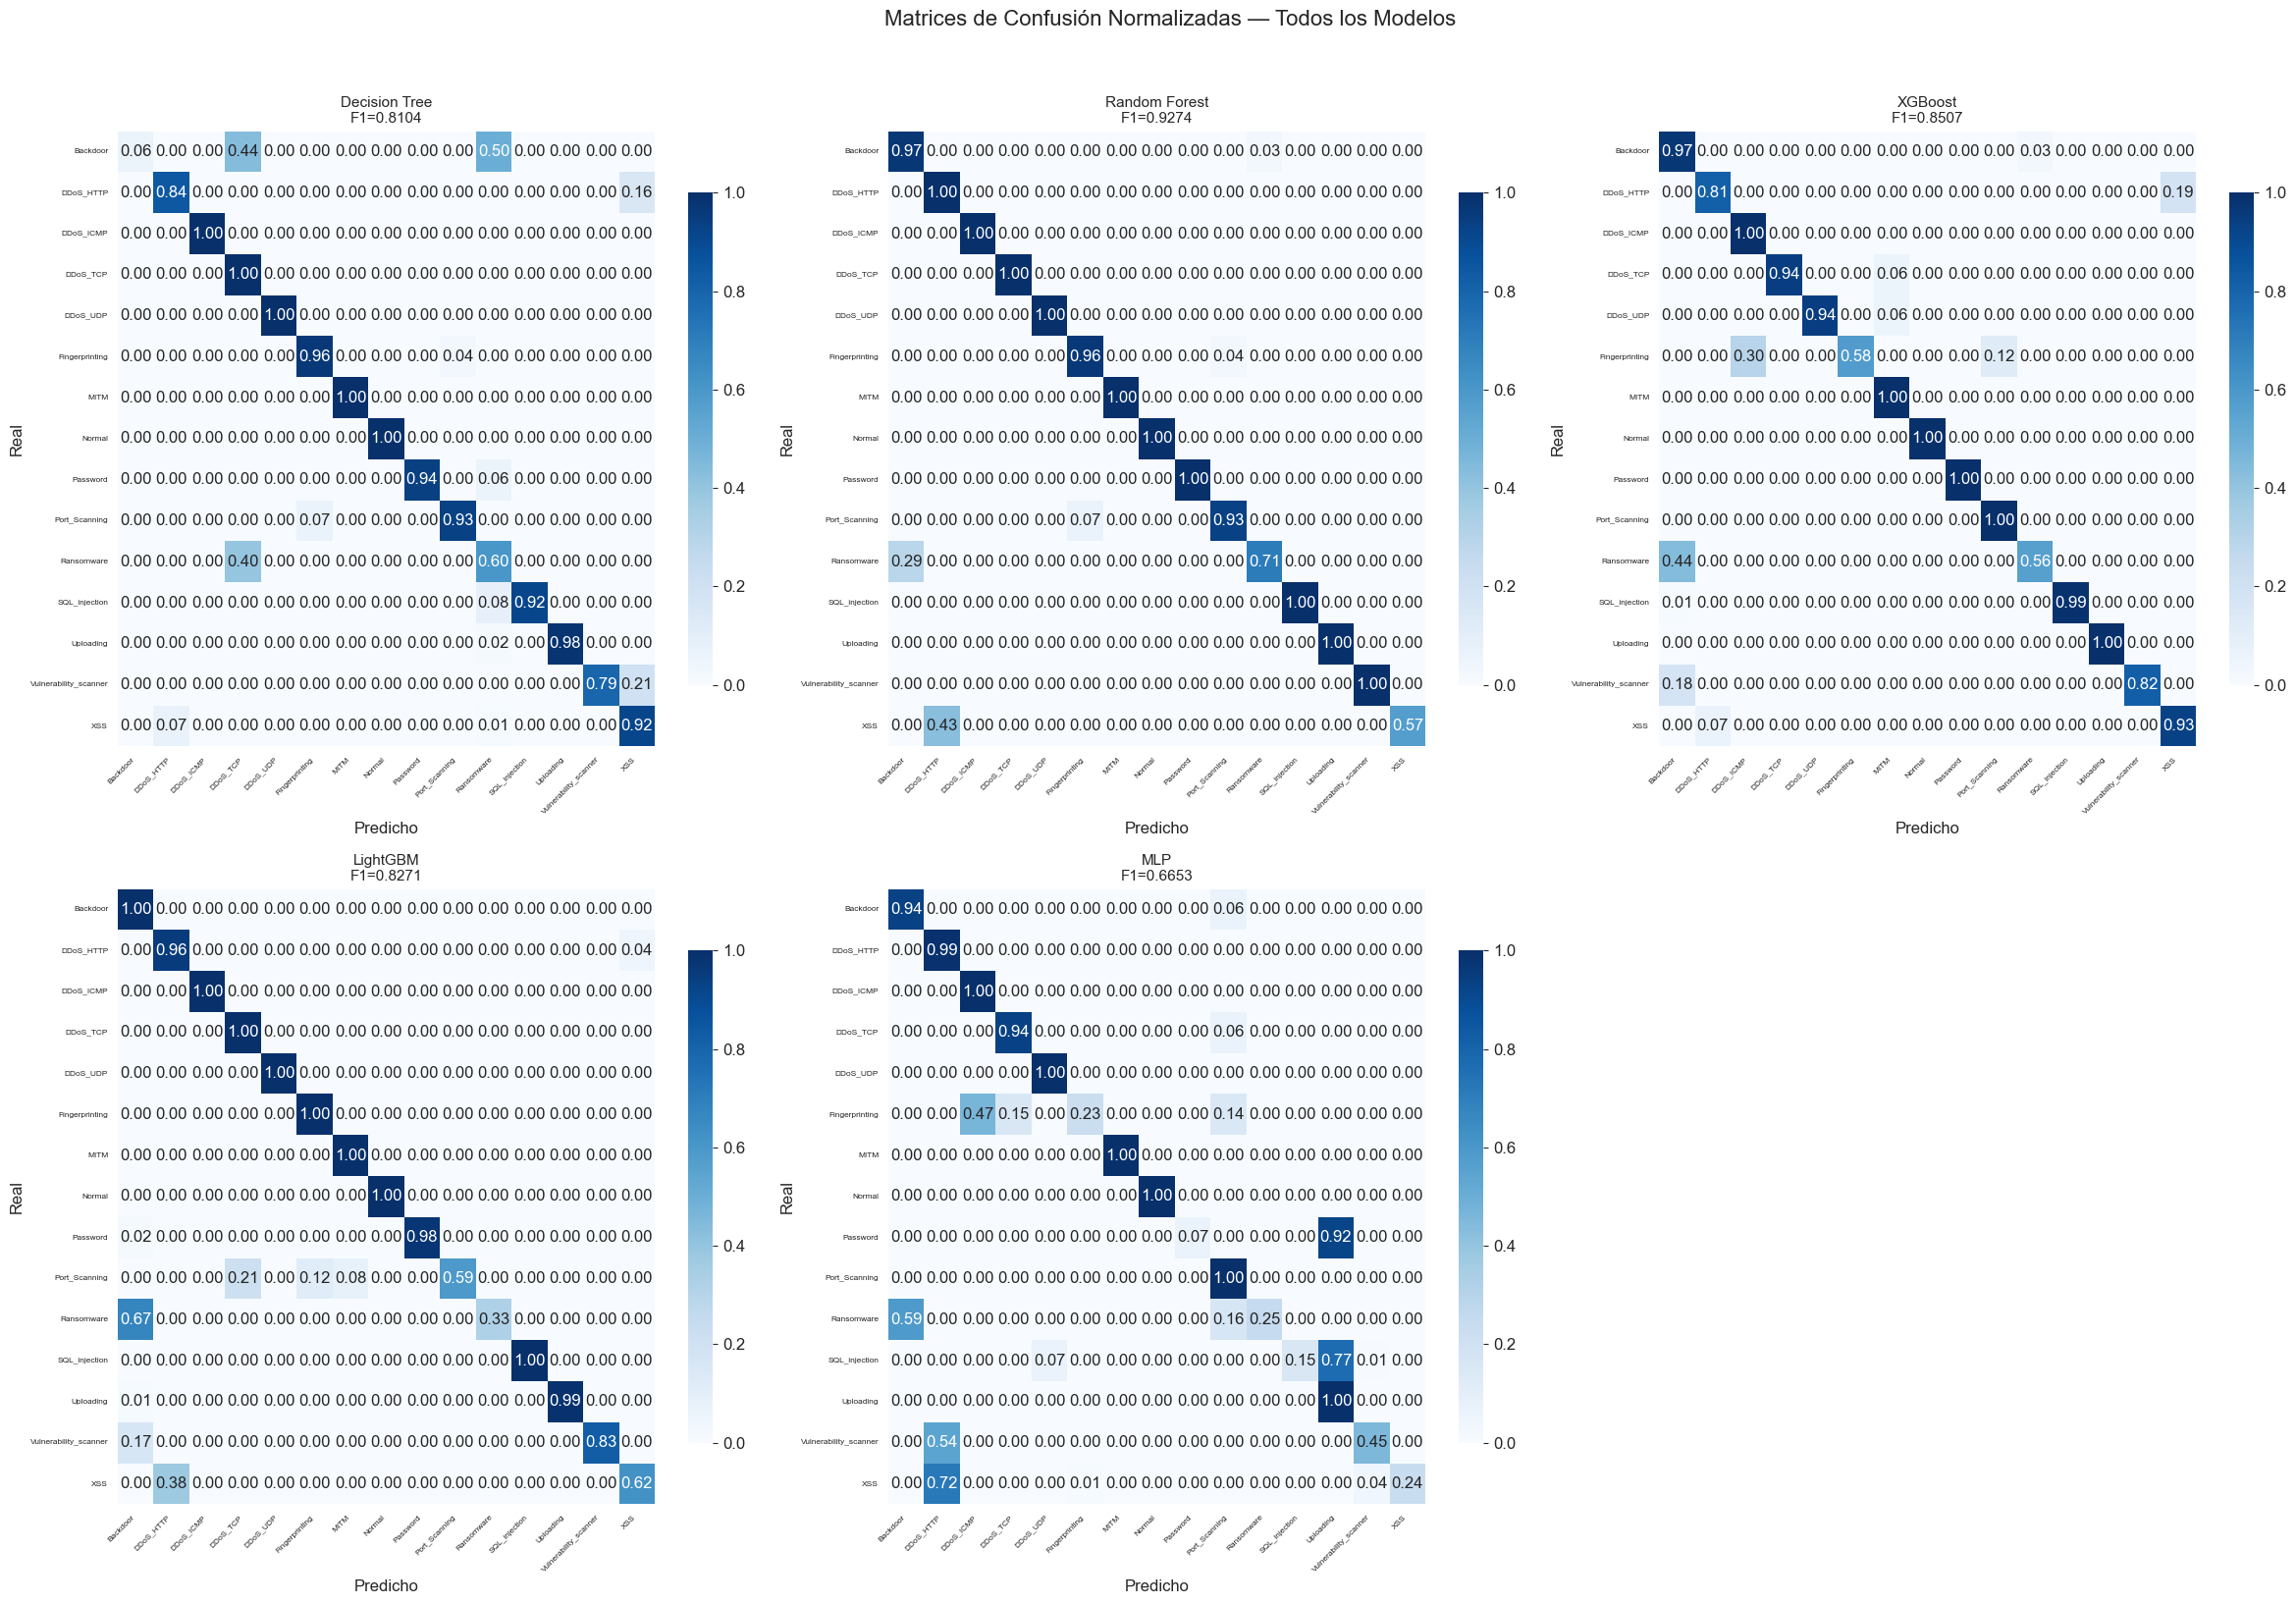

In [51]:
# === 7.2 Matrices de confusión ===
print("=" * 80)
print("7.2 — MATRICES DE CONFUSIÓN")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    if idx >= 5:
        break
    y_pred_m = model.predict(X_test_np)
    cm = confusion_matrix(y_test_enc, y_pred_m)
    # Normalizar por fila
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[idx], vmin=0, vmax=1, cbar_kws={"shrink": 0.8})
    axes[idx].set_title(f'{name}\nF1={results[name]["F1_macro"]:.4f}', fontsize=11)
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')
    axes[idx].tick_params(axis='both', labelsize=6)
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')
    plt.setp(axes[idx].get_yticklabels(), rotation=0)

# Ocultar subplot vacío
if len(trained_models) < 6:
    axes[5].set_visible(False)

plt.suptitle('Matrices de Confusión Normalizadas — Todos los Modelos', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png")
plt.show()

In [52]:
# === 7.3 ROC-AUC y PR-AUC ===
print("=" * 80)
print("7.3 — ROC-AUC Y PR-AUC")
print("=" * 80)

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

auc_results = {}
for name, model in trained_models.items():
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test_np)
            roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
            pr = average_precision_score(y_test_bin, y_proba, average='macro')
        else:
            roc = pr = float('nan')
        auc_results[name] = {'ROC-AUC': round(roc, 4), 'PR-AUC': round(pr, 4)}
        print(f"  {name:<20s} ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}")
    except Exception as e:
        print(f"  {name:<20s} Error: {e}")
        auc_results[name] = {'ROC-AUC': float('nan'), 'PR-AUC': float('nan')}


7.3 — ROC-AUC Y PR-AUC
  Decision Tree        ROC-AUC: 0.9507  PR-AUC: 0.8040
  Random Forest        ROC-AUC: 0.9999  PR-AUC: 0.9792
  XGBoost              ROC-AUC: 0.9957  PR-AUC: 0.9030
  LightGBM             ROC-AUC: 0.9997  PR-AUC: 0.9600
  MLP                  ROC-AUC: 0.9596  PR-AUC: 0.6493


In [53]:
# === 7.4 FPR Operacional ===
print("=" * 80)
print("7.4 — FALSE POSITIVE RATE (FPR) OPERACIONAL")
print("=" * 80)
print("(Clave para IDS: qué porcentaje de tráfico Normal se clasifica como ataque)\n")

normal_class_idx = list(le.classes_).index('Normal') if 'Normal' in le.classes_ else 0
for name, model in trained_models.items():
    y_pred_m = model.predict(X_test_np)
    # FPR = FP / (FP + TN) para la clase Normal
    normal_mask = y_test_enc == normal_class_idx
    if normal_mask.sum() > 0:
        fp = ((y_pred_m != normal_class_idx) & normal_mask).sum()
        tn = ((y_pred_m == normal_class_idx) & normal_mask).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f"  {name:<20s} FPR: {fpr:.4f} ({fpr*100:.2f}%)")
    else:
        print(f"  {name:<20s} No se encontró clase 'Normal'")

7.4 — FALSE POSITIVE RATE (FPR) OPERACIONAL
(Clave para IDS: qué porcentaje de tráfico Normal se clasifica como ataque)

  Decision Tree        FPR: 0.0000 (0.00%)
  Random Forest        FPR: 0.0000 (0.00%)
  XGBoost              FPR: 0.0000 (0.00%)
  LightGBM             FPR: 0.0000 (0.00%)
  MLP                  FPR: 0.0000 (0.00%)


7.5 — SHAP: EXPLICABILIDAD DEL MEJOR MODELO
Modelo para SHAP: Random Forest

--- 7.5a  SHAP Bar Plot (importancia global media) ---


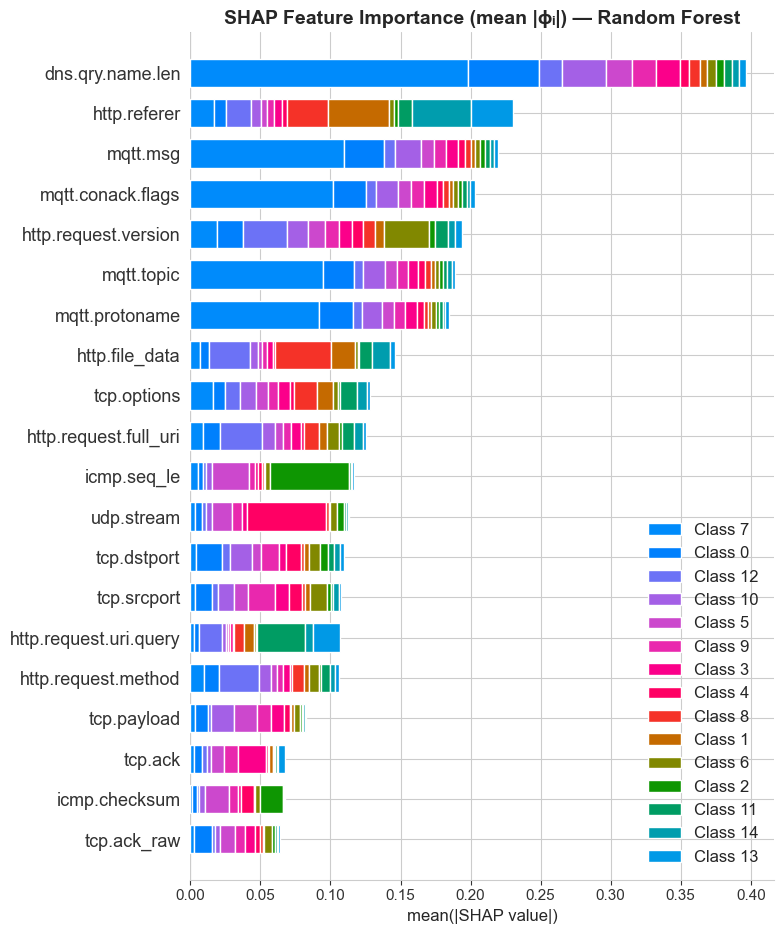

📄 Bar plot guardado en docs/figures/shap_importance_bar.png

--- 7.5b  SHAP Summary Plot (distribución de valores SHAP) ---


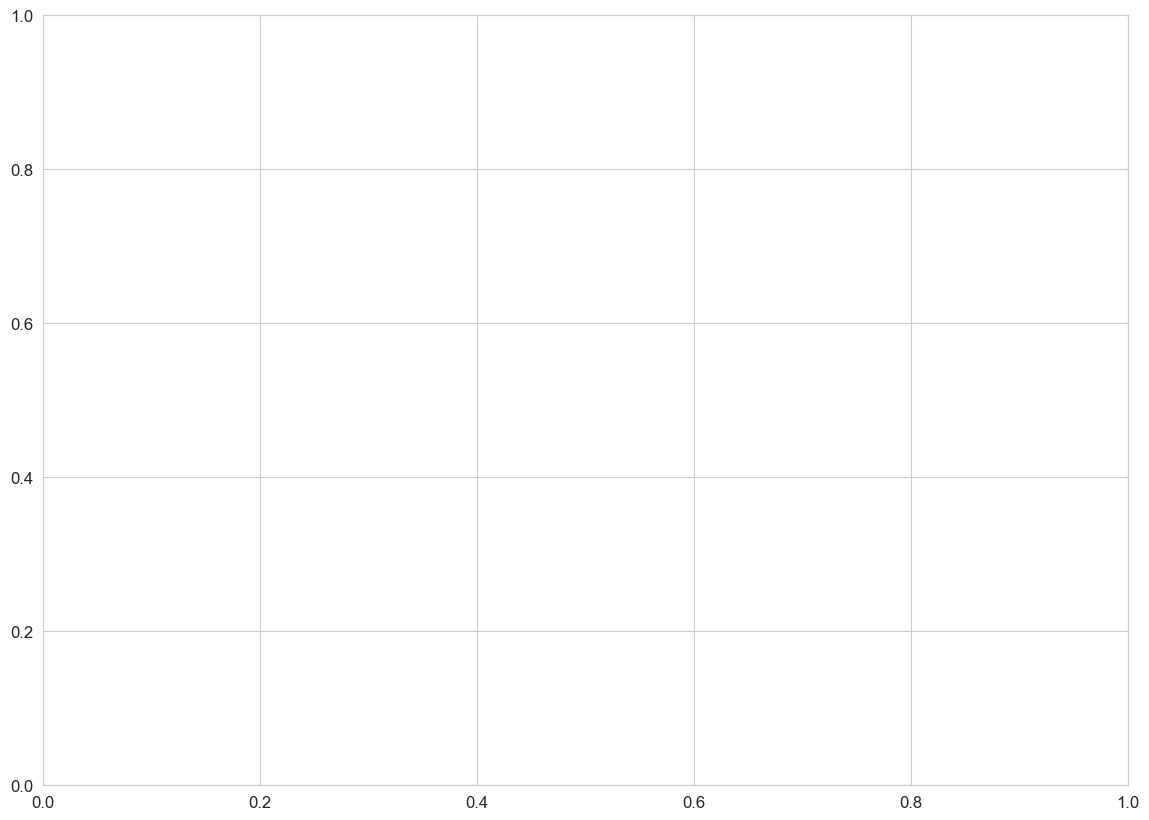

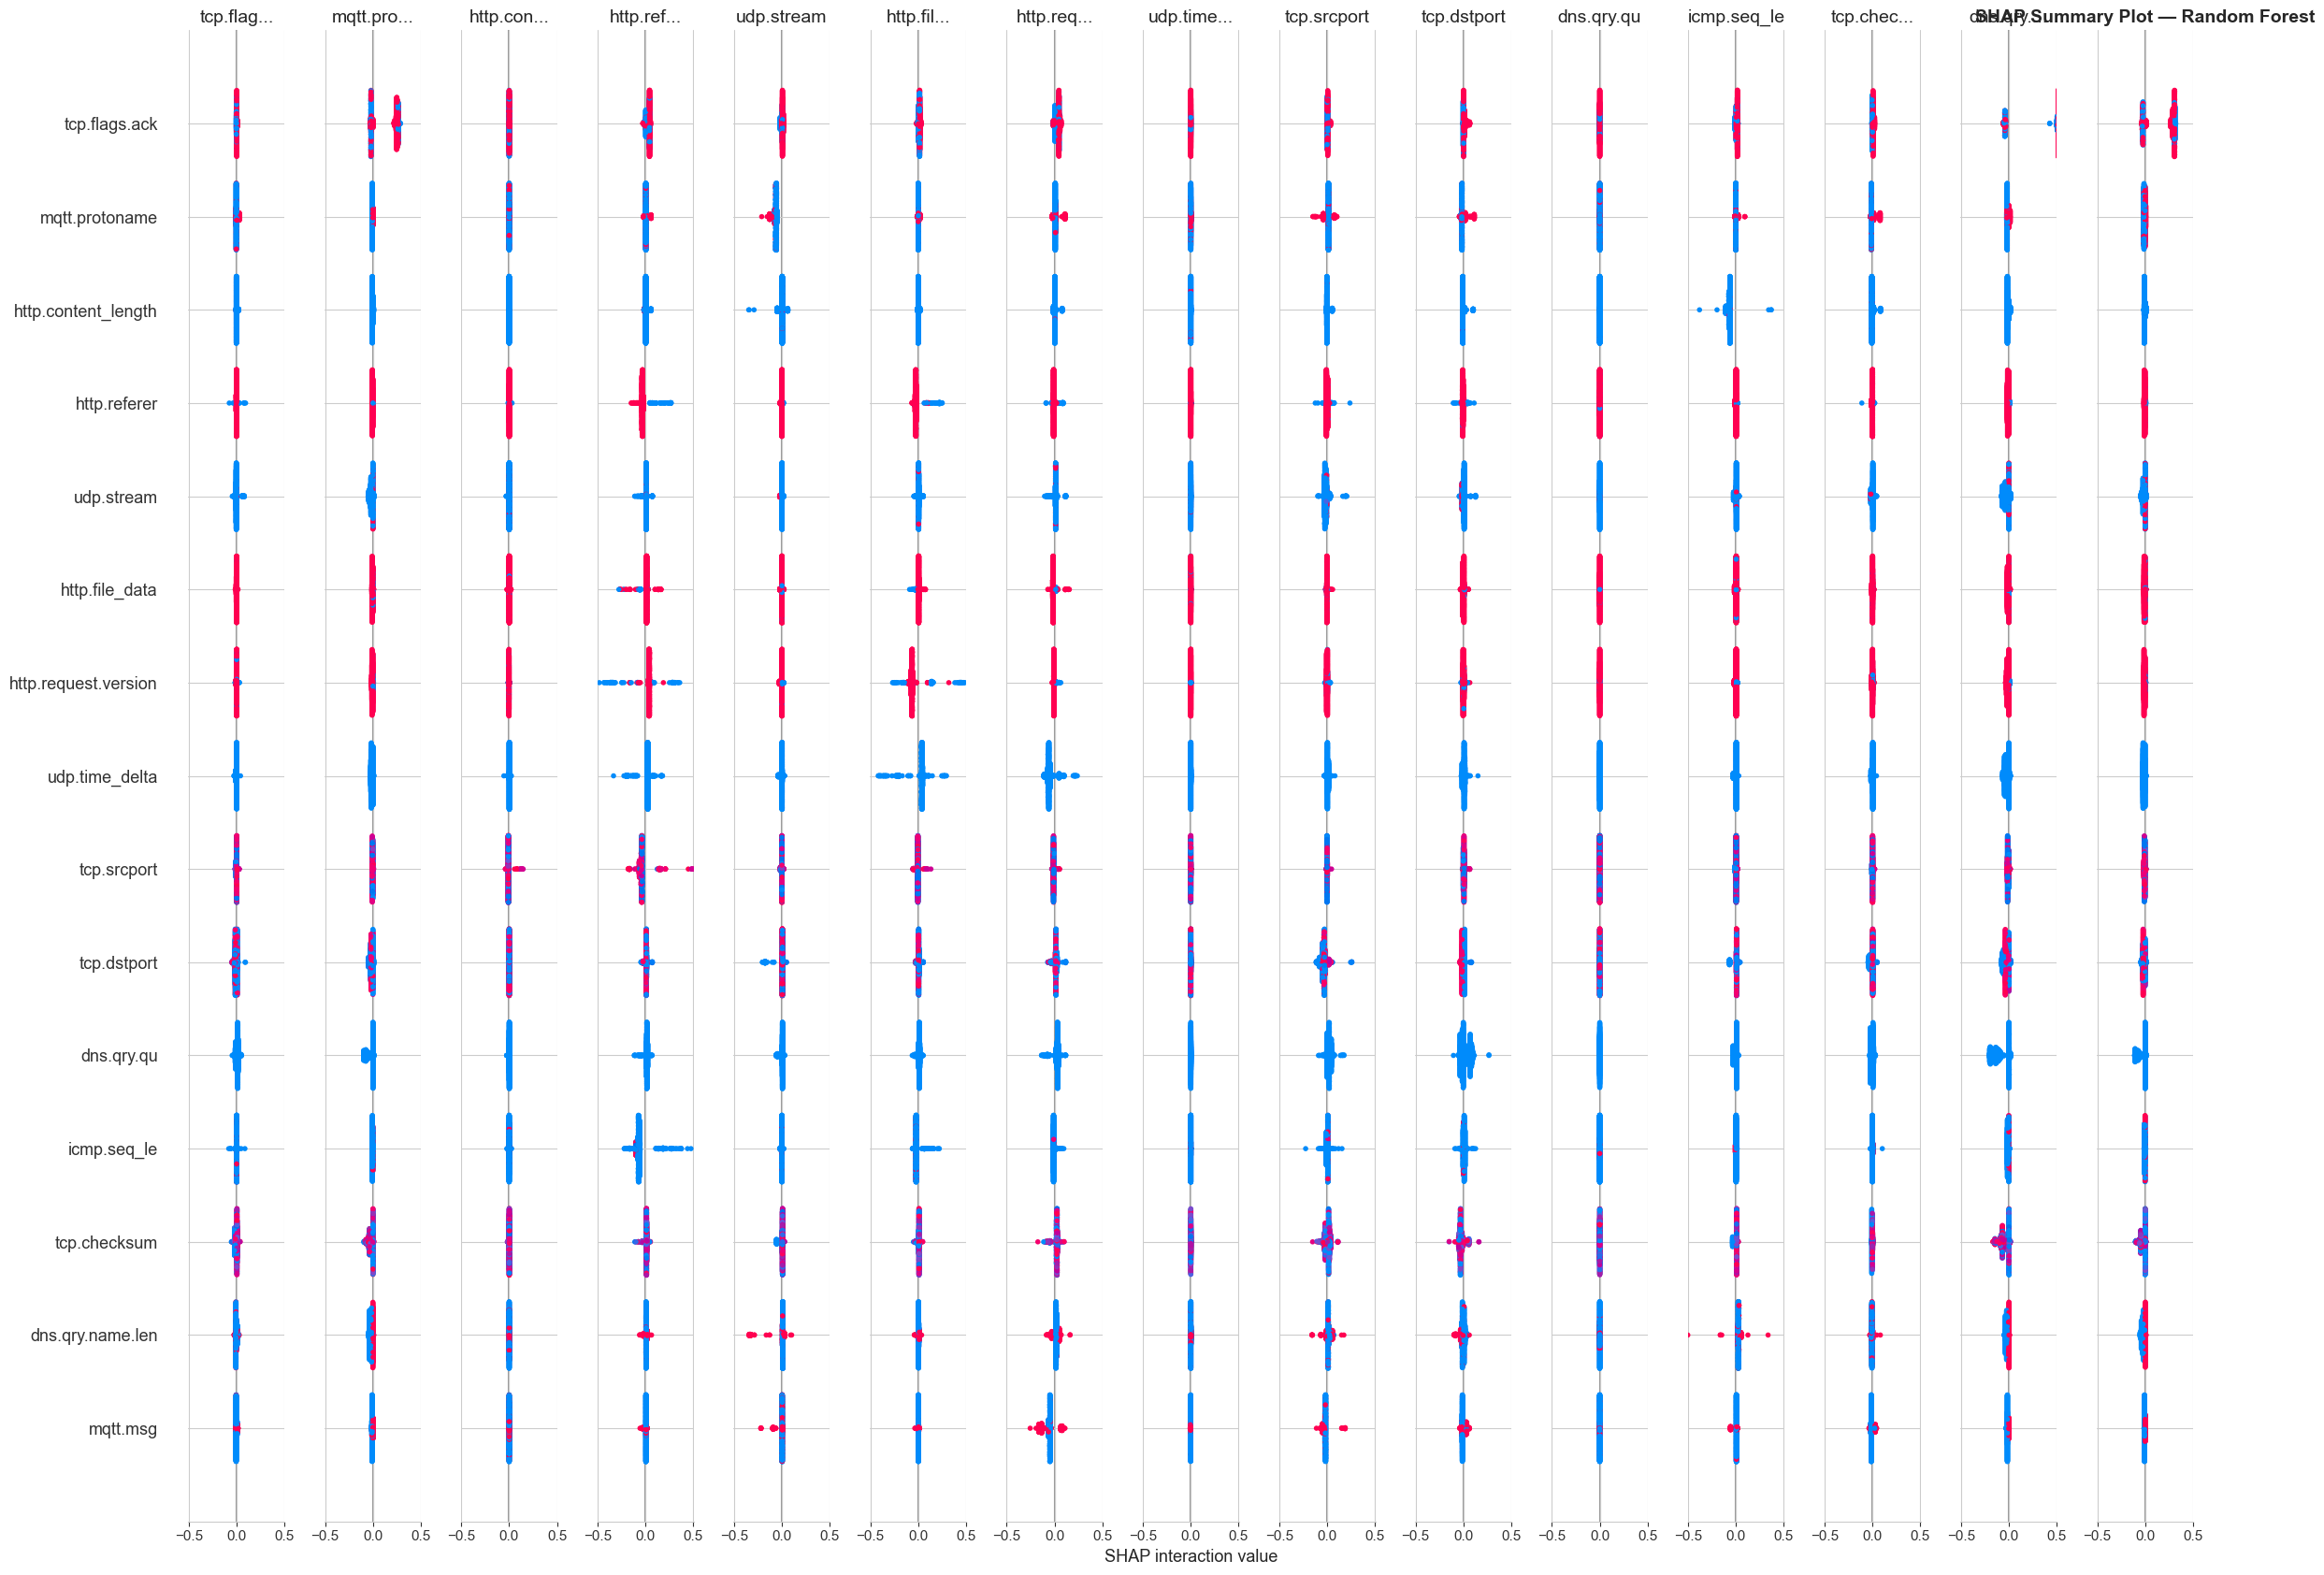

📄 Summary plot guardado en docs/figures/shap_summary_dot.png


In [57]:
# === 7.5 SHAP — Explicabilidad ===
print("=" * 80)
print("7.5 — SHAP: EXPLICABILIDAD DEL MEJOR MODELO")
print("=" * 80)

import shap
import numpy as np

# Usar el mejor modelo basado en árboles para SHAP (mucho más eficiente)
tree_models = {k: v for k, v in trained_models.items()
               if k in ["LightGBM", "XGBoost", "Random Forest"]}

if tree_models:
    shap_model_name = list(tree_models.keys())[0]
    shap_model = tree_models[shap_model_name]
    print(f"Modelo para SHAP: {shap_model_name}")

    # Sample para SHAP (es costoso computacionalmente)
    shap_sample_size = min(1000, len(X_test_np))
    X_shap = X_test_np[:shap_sample_size]
    feature_labels = consensus_features

    try:
        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(X_shap)

        # ── 7.5a  SHAP Bar Plot (importancia global media |ϕᵢ|) ──
        print("\n--- 7.5a  SHAP Bar Plot (importancia global media) ---")
        fig, ax = plt.subplots(figsize=(14, 10))
        shap.summary_plot(
            shap_values,
            X_shap,
            feature_names=feature_labels,
            plot_type="bar",
            show=False,
            max_display=20
        )
        plt.title(f'SHAP Feature Importance (mean |ϕᵢ|) — {shap_model_name}',
                  fontsize=14, fontweight='bold')
        plt.xlabel('mean(|SHAP value|)', fontsize=12)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "shap_importance_bar.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"📄 Bar plot guardado en docs/figures/shap_importance_bar.png")

        # ── 7.5b  SHAP Summary Plot (beeswarm / dot plot) ──
        print("\n--- 7.5b  SHAP Summary Plot (distribución de valores SHAP) ---")
        fig, ax = plt.subplots(figsize=(14, 10))
        shap.summary_plot(
            shap_values,
            X_shap,
            feature_names=feature_labels,
            show=False,
            max_display=20
        )
        plt.title(f'SHAP Summary Plot — {shap_model_name}',
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "shap_summary_dot.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"📄 Summary plot guardado en docs/figures/shap_summary_dot.png")

    except Exception as e:
        print(f"⚠️ Error en SHAP: {e}")
        print("   SHAP puede fallar con datasets muy grandes. Intentar con menos muestras.")
else:
    print("⚠️ No hay modelos basados en árboles para SHAP")


7.6 — SHAP WATERFALL: ANÁLISIS FORENSE DE UN ATAQUE MINORITARIO
Objetivo: explicación local de un verdadero positivo de clase minoritaria

Clases minoritarias candidatas:
  • MITM: 243 muestras en test
  • Fingerprinting: 200 muestras en test
  • Vulnerability_scanner: 10,022 muestras en test
  • Password: 10,031 muestras en test
  • Backdoor: 4,972 muestras en test
  • Ransomware: 2,185 muestras en test
  • SQL_injection: 10,241 muestras en test
  • XSS: 3,183 muestras en test
  • Uploading: 7,527 muestras en test

✅ Verdadero positivo encontrado para 'MITM' (muestra #2626 de 243 TPs disponibles)
   Valor base (ϕ₀): 0.0669
   Predicción final: 1.0000
   Clase real: MITM
   Clase predicha: MITM


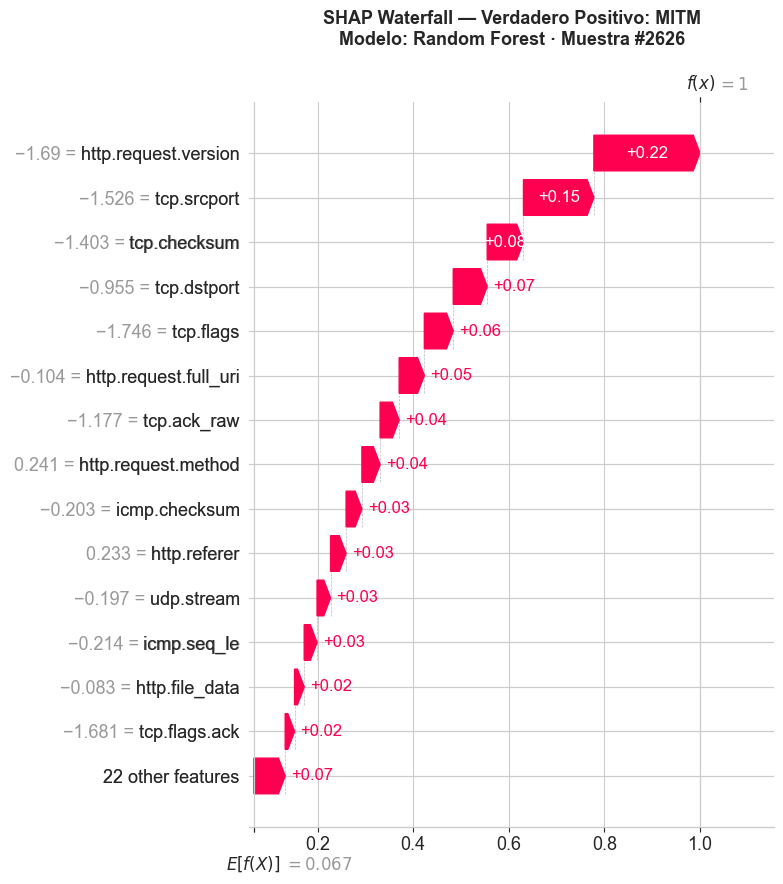


📄 Waterfall plot guardado en docs/figures/shap_waterfall_minority.png

📝 Top-5 features que determinaron la clasificación como 'MITM':
   1. http.request.version = -1.6900  →  SHAP = +0.2219  (▲ empuja hacia ataque)
   2. tcp.srcport = -1.5259  →  SHAP = +0.1473  (▲ empuja hacia ataque)
   3. tcp.checksum = -1.4032  →  SHAP = +0.0759  (▲ empuja hacia ataque)
   4. tcp.dstport = -0.9551  →  SHAP = +0.0711  (▲ empuja hacia ataque)
   5. tcp.flags = -1.7464  →  SHAP = +0.0605  (▲ empuja hacia ataque)


In [55]:
# === 7.6 SHAP Waterfall — Análisis forense de un ataque minoritario ===
print("=" * 80)
print("7.6 — SHAP WATERFALL: ANÁLISIS FORENSE DE UN ATAQUE MINORITARIO")
print("=" * 80)
print("Objetivo: explicación local de un verdadero positivo de clase minoritaria\n")

import shap
import numpy as np

# ── 1. Identificar clases minoritarias en el test set ──
class_counts = pd.Series(y_test_enc).value_counts().sort_values()

# Clases prioritarias para el análisis forense
priority_names = ["MITM", "Fingerprinting", "OS_Fingerprinting",
                  "Vulnerability_scanner", "Password", "Backdoor",
                  "Ransomware", "SQL_injection", "XSS", "Uploading"]

minority_candidates = []
for name in priority_names:
    if name in le.classes_:
        idx = list(le.classes_).index(name)
        count = int(class_counts.get(idx, 0))
        if count > 0:
            minority_candidates.append((name, idx, count))

# Fallback: si no hay coincidencias, usar las clases menos frecuentes (excl. Normal)
if not minority_candidates:
    for cls_idx in class_counts.index:
        name = le.classes_[cls_idx]
        if name != "Normal":
            minority_candidates.append((name, cls_idx, int(class_counts[cls_idx])))
        if len(minority_candidates) >= 5:
            break

print("Clases minoritarias candidatas:")
for name, idx, count in minority_candidates:
    print(f"  • {name}: {count:,} muestras en test")

# ── 2. Buscar un verdadero positivo (TP) ──
y_pred_all = shap_model.predict(X_test_np)

sample_idx = None
sample_class_name = None
sample_class_idx = None

for name, cls_idx, count in minority_candidates:
    tp_mask = (y_test_enc == cls_idx) & (y_pred_all == cls_idx)
    tp_indices = np.where(tp_mask)[0]
    if len(tp_indices) > 0:
        sample_idx = tp_indices[0]
        sample_class_name = name
        sample_class_idx = cls_idx
        print(f"\n✅ Verdadero positivo encontrado para '{name}' "
              f"(muestra #{sample_idx} de {len(tp_indices)} TPs disponibles)")
        break

if sample_idx is None:
    raise RuntimeError("⚠️ No se encontró ningún TP para clases minoritarias. "
                       "Revisa el rendimiento del modelo en estas clases.")

# ── 3. Calcular SHAP values para la muestra seleccionada ──
X_sample = X_test_np[sample_idx : sample_idx + 1]

explainer_local = shap.TreeExplainer(shap_model)
shap_values_sample = explainer_local.shap_values(X_sample)

# Extraer los SHAP values de la clase predicha
if isinstance(shap_values_sample, list):
    # SHAP < 0.40 devuelve lista de arrays (una por clase)
    sv = shap_values_sample[sample_class_idx][0]
    base_val = explainer_local.expected_value[sample_class_idx]
elif shap_values_sample.ndim == 3:
    # SHAP >= 0.40 devuelve array 3D (muestras × features × clases)
    sv = shap_values_sample[0, :, sample_class_idx]
    base_val = explainer_local.expected_value[sample_class_idx]
else:
    sv = shap_values_sample[0]
    base_val = (explainer_local.expected_value
                if np.isscalar(explainer_local.expected_value)
                else explainer_local.expected_value[0])

print(f"   Valor base (ϕ₀): {base_val:.4f}")
print(f"   Predicción final: {base_val + sv.sum():.4f}")
print(f"   Clase real: {le.classes_[y_test_enc[sample_idx]]}")
print(f"   Clase predicha: {le.classes_[y_pred_all[sample_idx]]}")

# ── 4. Generar Waterfall Plot ──
explanation = shap.Explanation(
    values=sv,
    base_values=base_val,
    data=X_sample[0],
    feature_names=list(consensus_features)
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — Verdadero Positivo: {sample_class_name}\n"
    f"Modelo: {shap_model_name} · Muestra #{sample_idx}",
    fontsize=13, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_waterfall_minority.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n📄 Waterfall plot guardado en docs/figures/shap_waterfall_minority.png")

# ── 5. Resumen textual para la memoria ──
top_k = 5
sorted_idx = np.argsort(np.abs(sv))[::-1][:top_k]
print(f"\n📝 Top-{top_k} features que determinaron la clasificación como '{sample_class_name}':")
for rank, fi in enumerate(sorted_idx, 1):
    fname = consensus_features[fi]
    fval  = X_sample[0][fi]
    shap_contrib = sv[fi]
    direction = "▲ empuja hacia ataque" if shap_contrib > 0 else "▼ empuja hacia Normal"
    print(f"   {rank}. {fname} = {fval:.4f}  →  SHAP = {shap_contrib:+.4f}  ({direction})")


In [58]:
# === 7.7 Concordancia: ranking SHAP vs. selección por consenso ===
print("=" * 80)
print("7.7 — CONCORDANCIA ENTRE SELECCIÓN DE FEATURES Y RANKING SHAP")
print("=" * 80)
print("(Elaboración propia a partir del notebook)\n")

import numpy as np
import pandas as pd

# ── 1. Calcular importancia SHAP global: mean(|ϕᵢ|) por feature ──
# shap_values viene de la celda 7.5 (puede ser lista o array 3D)
if isinstance(shap_values, list):
    # SHAP < 0.40: lista de arrays (n_samples, n_features), uno por clase
    shap_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # media entre clases
    shap_importance = np.mean(shap_abs, axis=0)                     # media entre muestras
elif shap_values.ndim == 3:
    # SHAP >= 0.40: array (n_samples, n_features, n_classes)
    shap_importance = np.mean(np.abs(shap_values), axis=(0, 2))     # media muestras + clases
else:
    # Binario
    shap_importance = np.mean(np.abs(shap_values), axis=0)

# Ranking SHAP (1 = más importante)
shap_ranking_idx = np.argsort(shap_importance)[::-1]
shap_rank_map = {feat_idx: rank + 1 for rank, feat_idx in enumerate(shap_ranking_idx)}

# ── 2. Ranking de selección por consenso ──
# consensus_features contiene las features seleccionadas;
# su orden refleja el ranking del pipeline de selección.
consensus_rank_map = {name: rank + 1 for rank, name in enumerate(consensus_features)}

# ── 3. Construir tabla top-10 SHAP ──
top_n = 10
rows = []
for rank in range(top_n):
    feat_idx = shap_ranking_idx[rank]
    feat_name = consensus_features[feat_idx]
    shap_pos = rank + 1
    consensus_pos = feat_idx + 1  # posición en la lista de consenso
    mean_shap = shap_importance[feat_idx]
    rows.append({
        "Ranking SHAP": shap_pos,
        "Feature": feat_name,
        "mean(|ϕᵢ|)": f"{mean_shap:.4f}",
        "Posición en consenso": consensus_pos
    })

df_concordance = pd.DataFrame(rows)

# ── 4. Calcular métricas de concordancia ──
shap_top10_names = set(df_concordance["Feature"])
consensus_top10_names = set(list(consensus_features)[:top_n])
overlap = shap_top10_names & consensus_top10_names
overlap_pct = len(overlap) / top_n * 100

# Correlación de Spearman entre los dos rankings (sobre todas las features)
from scipy.stats import spearmanr
ranks_shap = [shap_rank_map[i] for i in range(len(consensus_features))]
ranks_consensus = [i + 1 for i in range(len(consensus_features))]
rho, p_value = spearmanr(ranks_shap, ranks_consensus)

# ── 5. Mostrar tabla ──
print(df_concordance.to_string(index=False))

print(f"\n{'─' * 60}")
print(f"📊 Solapamiento top-{top_n}: {len(overlap)}/{top_n} features "
      f"({overlap_pct:.0f}%)")
if overlap:
    print(f"   Features comunes: {', '.join(sorted(overlap))}")
print(f"📊 Correlación de Spearman (ρ): {rho:.4f}  (p = {p_value:.2e})")

if overlap_pct >= 70:
    print("\n✅ Alto solapamiento → la selección por consenso y SHAP convergen,")
    print("   reforzando la robustez metodológica del pipeline completo.")
elif overlap_pct >= 40:
    print("\n⚠️ Solapamiento moderado → ambos métodos coinciden parcialmente.")
    print("   Las diferencias pueden deberse a que la selección por consenso")
    print("   optimiza relevancia univariante, mientras SHAP captura")
    print("   contribuciones no lineales e interacciones entre features.")
else:
    print("\n⚠️ Bajo solapamiento → los criterios de selección y SHAP")
    print("   priorizan aspectos diferentes de los datos.")

# ── 6. Guardar tabla como CSV ──
csv_path = FIGURES_DIR.parent / "shap_vs_consensus_ranking.csv"
df_concordance.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\n📄 Tabla guardada en {csv_path.relative_to(PROJECT_ROOT)}")


7.7 — CONCORDANCIA ENTRE SELECCIÓN DE FEATURES Y RANKING SHAP
(Elaboración propia a partir del notebook)

 Ranking SHAP               Feature mean(|ϕᵢ|)  Posición en consenso
            1      dns.qry.name.len     0.0264                     6
            2          http.referer     0.0153                     2
            3              mqtt.msg     0.0147                     7
            4     mqtt.conack.flags     0.0136                    18
            5  http.request.version     0.0129                     9
            6            mqtt.topic     0.0126                    31
            7        mqtt.protoname     0.0123                     5
            8        http.file_data     0.0098                    12
            9           tcp.options     0.0086                    21
           10 http.request.full_uri     0.0083                    26

────────────────────────────────────────────────────────────
📊 Solapamiento top-10: 5/10 features (50%)
   Features comunes: dns.qry.n

---
## FASE 8 — Documentación para la Memoria
### Comparación crítica con resultados del paper original
---

In [59]:
print("=" * 80)
print("FASE 8 — COMPARACIÓN CON PAPER ORIGINAL (Ferrag et al., 2022)")
print("=" * 80)

# Resultados reportados en el paper original
PAPER_RESULTS = {
    "DT (Paper)":   {"Accuracy": 0.9392, "Precision": 0.9450, "Recall": 0.9392, "F1": 0.9376},
    "RF (Paper)":   {"Accuracy": 0.9475, "Precision": 0.9541, "Recall": 0.9475, "F1": 0.9463},
    "DNN (Paper)":  {"Accuracy": 0.9523, "Precision": 0.9543, "Recall": 0.9523, "F1": 0.9515},
    "KNN (Paper)":  {"Accuracy": 0.6168, "Precision": 0.5746, "Recall": 0.6168, "F1": 0.5607},
}

# Nuestros resultados
our_results = {}
for name in results:
    our_results[f"{name} (Nuestro)"] = {
        "Accuracy": results[name]['Accuracy'],
        "Precision": results[name]['Precision_macro'],
        "Recall": results[name]['Recall_macro'],
        "F1": results[name]['F1_macro'],
        "Inference_ms": results[name]['Inference_ms_per_sample']
    }

# Combinar
comparison = pd.DataFrame({**PAPER_RESULTS, **our_results}).T
comparison = comparison.round(4)

print("\n📊 TABLA COMPARATIVA: Nuestros resultados vs. Paper original")
print("=" * 80)
print(comparison.to_string())

comparison.to_csv(PROJECT_ROOT / "docs" / "paper_comparison.csv")
print(f"\n📄 Tabla guardada en docs/paper_comparison.csv")

# Análisis crítico
print("\n" + "=" * 80)
print("ANÁLISIS CRÍTICO")
print("=" * 80)
print("""
📝 NOTAS PARA LA MEMORIA:

1. REPRODUCIBILIDAD del F1 > 99% del paper:
   - El paper reporta DNN con F1=0.9515 (multiclase, 15 clases).
   - Versiones más recientes del paper/dataset reportan F1 > 99% pero
     potencialmente incluyen features con alta mutual information que
     podrían constituir leakage (verificar sección 3.8 de este notebook).

2. DIFERENCIAS METODOLÓGICAS:
   - Paper: 1176 features → 61 por correlación
   - Nuestro: 61 features → N por ANOVA + LightGBM + correlación
   - Paper: Split no especificado (posible leakage temporal)
   - Nuestro: 80/20 estratificado con shuffle

3. VALOR AÑADIDO de este TFM:
   - Tiempo de inferencia por muestra (ms) — crítico para Raspberry Pi
   - Análisis de leakage no presente en el paper original
   - SMOTE aplicado correctamente (solo en train)
   - SHAP para explicabilidad

4. RECOMENDACIÓN para despliegue en Raspberry Pi:
   - Priorizar LightGBM o Random Forest (balance F1 vs inference time)
   - Evitar MLP/DNN si el tiempo de inferencia es crítico
""")

FASE 8 — COMPARACIÓN CON PAPER ORIGINAL (Ferrag et al., 2022)

📊 TABLA COMPARATIVA: Nuestros resultados vs. Paper original
                         Accuracy  Precision  Recall      F1  Inference_ms
DT (Paper)                 0.9392     0.9450  0.9392  0.9376           NaN
RF (Paper)                 0.9475     0.9541  0.9475  0.9463           NaN
DNN (Paper)                0.9523     0.9543  0.9523  0.9515           NaN
KNN (Paper)                0.6168     0.5746  0.6168  0.5607           NaN
Decision Tree (Nuestro)    0.9744     0.8544  0.8634  0.8104        0.0001
Random Forest (Nuestro)    0.9945     0.9377  0.9433  0.9274        0.0068
XGBoost (Nuestro)          0.9838     0.8643  0.9029  0.8507        0.0110
LightGBM (Nuestro)         0.9842     0.8534  0.8861  0.8271        0.0347
MLP (Nuestro)              0.9352     0.8524  0.6839  0.6653        0.0390

📄 Tabla guardada en docs/paper_comparison.csv

ANÁLISIS CRÍTICO

📝 NOTAS PARA LA MEMORIA:

1. REPRODUCIBILIDAD del F1 > 99% de

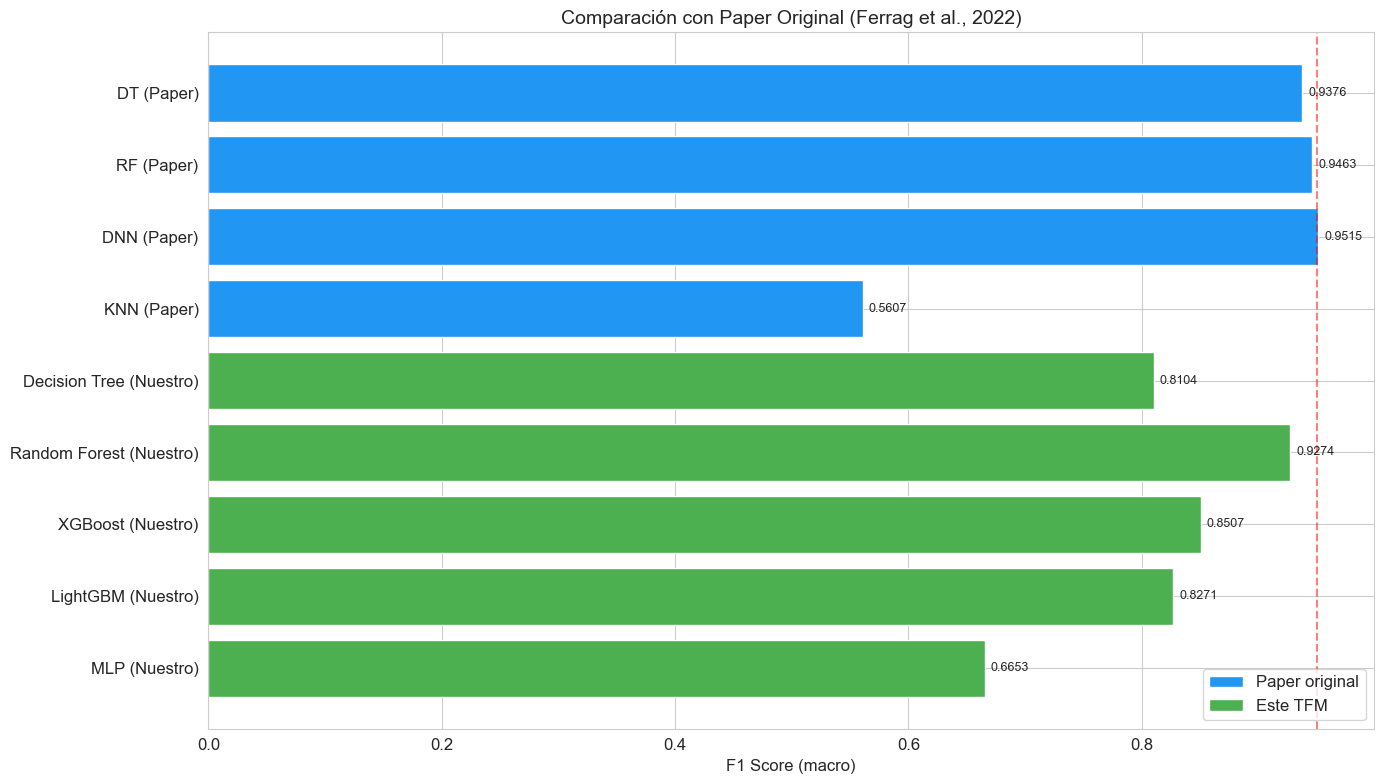

In [60]:
# === Gráfico final: Nuestros resultados vs Paper ===
fig, ax = plt.subplots(figsize=(14, 8))

paper_names = list(PAPER_RESULTS.keys())
our_names = list(our_results.keys())

# F1 scores
paper_f1 = [PAPER_RESULTS[n]["F1"] for n in paper_names]
our_f1 = [our_results[n]["F1"] for n in our_names]

all_names = paper_names + our_names
all_f1 = paper_f1 + our_f1
colors = ['#2196F3'] * len(paper_names) + ['#4CAF50'] * len(our_names)

bars = ax.barh(all_names[::-1], all_f1[::-1], color=colors[::-1])
ax.set_xlabel('F1 Score (macro)')
ax.set_title('Comparación con Paper Original (Ferrag et al., 2022)')
ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.5, label='F1 = 0.95')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Paper original'),
                   Patch(facecolor='#4CAF50', label='Este TFM')]
ax.legend(handles=legend_elements, loc='lower right')

for bar, val in zip(bars, all_f1[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "paper_comparison.png")
plt.show()

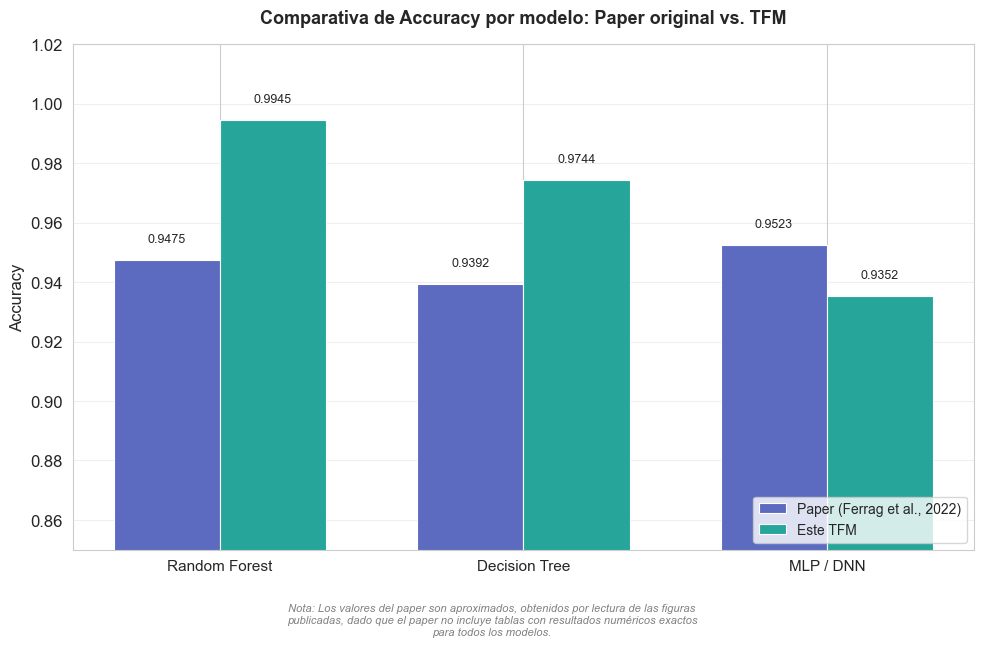

📄 Gráfico guardado en docs/figures/accuracy_paper_vs_tfm.png


In [61]:
# === Comparativa visual de Accuracy: Paper vs. TFM (barras agrupadas) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Pares comparables: (Nombre grupo, clave paper, clave TFM)
model_pairs = [
    ("Random Forest",  "RF (Paper)",  "Random Forest (Nuestro)"),
    ("Decision Tree",  "DT (Paper)",  "Decision Tree (Nuestro)"),
    ("MLP / DNN",      "DNN (Paper)", "MLP (Nuestro)"),
]

paper_acc = [PAPER_RESULTS[pair[1]]["Accuracy"] for pair in model_pairs]
tfm_acc   = [our_results[pair[2]]["Accuracy"]    for pair in model_pairs]
group_labels = [pair[0] for pair in model_pairs]

x = np.arange(len(group_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_paper = ax.bar(x - width/2, paper_acc, width,
                    label="Paper (Ferrag et al., 2022)",
                    color="#5C6BC0", edgecolor="white", linewidth=0.8)
bars_tfm   = ax.bar(x + width/2, tfm_acc,   width,
                    label="Este TFM",
                    color="#26A69A", edgecolor="white", linewidth=0.8)

# Etiquetas de valor sobre cada barra
for bar in bars_paper:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars_tfm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

# Configuración de ejes
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Comparativa de Accuracy por modelo: Paper original vs. TFM",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(group_labels, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=10, loc="lower right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.grid(axis="y", alpha=0.3)

# Nota al pie
fig.text(0.5, -0.02,
         "Nota: Los valores del paper son aproximados, obtenidos por lectura de las figuras\n"
         "publicadas, dado que el paper no incluye tablas con resultados numéricos exactos\n"
         "para todos los modelos.",
         ha="center", va="top", fontsize=8, fontstyle="italic", color="gray")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_paper_vs_tfm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📄 Gráfico guardado en docs/figures/accuracy_paper_vs_tfm.png")


In [45]:
# === Guardar modelos y artefactos finales ===
print("=" * 80)
print("GUARDADO DE ARTEFACTOS FINALES")
print("=" * 80)

import joblib

models_dir = PROJECT_ROOT / "data" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

for name, model in trained_models.items():
    model_path = models_dir / f"{name.lower().replace(' ', '_')}_model.joblib"
    joblib.dump(model, model_path)
    print(f"  💾 {name} → {model_path}")

# Guardar scaler y encoder
joblib.dump(scaler, models_dir / "scaler.joblib")
joblib.dump(le, models_dir / "label_encoder.joblib")
joblib.dump(consensus_features, models_dir / "selected_features.joblib")
print(f"  💾 Scaler → {models_dir / 'scaler.joblib'}")
print(f"  💾 LabelEncoder → {models_dir / 'label_encoder.joblib'}")
print(f"  💾 Features → {models_dir / 'selected_features.joblib'}")

# Resumen final
print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("=" * 80)
print(f"""
📊 Resumen:
   Dataset: Edge-IIoTset ({df.shape[0]:,} muestras, {df.shape[1]} columnas)
   Clases: {len(le.classes_)} ({', '.join(le.classes_)})
   Features seleccionadas: {len(consensus_features)}
   Mejor modelo: {best_model_name} (F1={results[best_model_name]['F1_macro']:.4f})

📁 Archivos generados:
   docs/figures/*.png — Gráficos para la memoria
   docs/attack_taxonomy.json — Taxonomía de ataques
   docs/class_distribution.csv — Distribución de clases
   docs/anova_feature_ranking.csv — Ranking ANOVA
   docs/model_comparison.csv — Comparativa de modelos
   docs/paper_comparison.csv — Comparación con paper
   data/models/*.joblib — Modelos entrenados
   data/processed/edge_iiot_dataset.parquet — Dataset en Parquet
""")




GUARDADO DE ARTEFACTOS FINALES
  💾 Decision Tree → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\decision_tree_model.joblib
  💾 Random Forest → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\random_forest_model.joblib
  💾 XGBoost → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\xgboost_model.joblib
  💾 LightGBM → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\lightgbm_model.joblib
  💾 MLP → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\mlp_model.joblib
  💾 Scaler → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\scaler.joblib
  💾 LabelEncoder → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\label_encoder.joblib
  💾 Features → c:\Users\Luis\Documents\GitHub\IPS_IDS_Raspberry_IA\data\models\selected_features.joblib

✅ ANÁLISIS COMPLETO FINALIZADO

📊 Resumen:
   Dataset: Edge-IIoTset (2,219,201 muestras, 63 columnas)
   Clases: 15 (Backdoor, DDoS_HTTP, DDoS_ICMP, DDoS_TC